# Trabajo Práctico AA1 - Clasificación

In [1]:
%%capture
%pip install -r requirements-notebook.txt

In [2]:
# manipulación, visualización y modelado.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap

# separación de datos, modelos y métricas.
from sklearn.base import clone
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import classification_report
from sklearn.metrics import roc_curve, roc_auc_score, auc
import warnings
warnings.simplefilter('ignore')
import optuna
import tensorflow as tf
import json
import sys
from pathlib import Path

# preprocesamiento fold-local.
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
SRC_DIR = Path("src").resolve()
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))
from weather_preprocessing import (
    CATEGORICAL_COLUMNS,
    KNN_COLUMNS,
    MEDIAN_COLUMNS,
    MODE_COLUMNS,
    NUMERIC_COLUMNS,
    build_weather_preprocessor,
    prepare_pycaret_frame,
)
import joblib
# visualización de ubicaciones.
from folium import Map, Marker, Icon
from sklearn.cluster import KMeans
from pycaret.classification import *


## Ítem 1: Análisis descriptivo

In [3]:
# Cargamos el dataset
df_original = pd.read_csv("data/weatherAUS_2026C1.csv")
df_original.head()

,Unnamed: 0,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,...,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow,RainfallTomorrow
0,0,2008-12-01,Albury,13.6,22.5,0.6,NaN,NaN,W,45.0,...,23.8,1008.1,1007.2,8.0,NaN,16.8,20.8,No,No,0.0
1,1,2008-12-02,Albury,7.3,25.8,0.0,NaN,NaN,WNW,44.0,...,22.1,1011.1,1007.5,NaN,NaN,18.3,24.6,No,No,0.0
2,2,2008-12-03,Albury,13.2,26.2,0.0,NaN,NaN,WSW,46.0,...,31.5,1007.3,1009.4,NaN,2.0,21.2,23.4,No,No,0.0
3,3,2008-12-04,Albury,10.0,28.8,0.0,NaN,NaN,NE,23.0,...,18.5,1017.6,1012.4,NaN,NaN,17.4,26.3,No,No,1.0
4,4,2008-12-05,Albury,17.4,32.4,1.0,NaN,NaN,W,41.0,...,34.6,1010.9,1005.9,7.0,8.0,17.9,29.1,No,No,0.2


In [4]:
#copiamos el dataset para mantener el original
df = df_original.copy()

In [5]:
# revisamos las columnas
df.columns

Index(['Unnamed: 0', 'Date', 'Location', 'MinTemp', 'MaxTemp', 'Rainfall',
       'Evaporation', 'Sunshine', 'WindGustDir', 'WindGustSpeed', 'WindDir9am',
       'WindDir3pm', 'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am',
       'Humidity3pm', 'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm',
       'Temp9am', 'Temp3pm', 'RainToday', 'RainTomorrow', 'RainfallTomorrow'],
      dtype='object')

In [6]:
# revisamos cantidad de filas y columnas
df.shape

(145412, 25)

In [7]:
# revisamos tipos de datos y valores no nulos
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145412 entries, 0 to 145411
Data columns (total 25 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        145412 non-null  int64  
 1   Date              145412 non-null  object 
 2   Location          145412 non-null  object 
 3   MinTemp           143928 non-null  float64
 4   MaxTemp           144159 non-null  float64
 5   Rainfall          142152 non-null  float64
 6   Evaporation       82658 non-null   float64
 7   Sunshine          75616 non-null   float64
 8   WindGustDir       135096 non-null  object 
 9   WindGustSpeed     135159 non-null  float64
 10  WindDir9am        134850 non-null  object 
 11  WindDir3pm        141186 non-null  object 
 12  WindSpeed9am      143645 non-null  float64
 13  WindSpeed3pm      142351 non-null  float64
 14  Humidity9am       142759 non-null  float64
 15  Humidity3pm       140907 non-null  float64
 16  Pressure9am       13

### Descripción de variables

- Date: fecha de la observación.
- Location: ciudad o estación meteorológica donde se tomó la observación.
- MinTemp: temperatura mínima registrada durante el día.
- MaxTemp: temperatura máxima registrada durante el día.
- Rainfall: cantidad de lluvia registrada durante el día.
- Evaporation: evaporación registrada.
- Sunshine: cantidad de horas de sol.
- WindGustDir: dirección de la ráfaga de viento más fuerte.
- WindGustSpeed: velocidad de la ráfaga de viento más fuerte.
- WindDir9am: dirección del viento a las 9am.
- WindDir3pm: dirección del viento a las 3pm.
- WindSpeed9am: velocidad del viento a las 9am.
- WindSpeed3pm: velocidad del viento a las 3pm.
- Humidity9am: humedad a las 9am.
- Humidity3pm: humedad a las 3pm.
- Pressure9am: presión atmosférica a las 9am.
- Pressure3pm: presión atmosférica a las 3pm.
- Cloud9am: nubosidad a las 9am.
- Cloud3pm: nubosidad a las 3pm.
- Temp9am: temperatura a las 9am.
- Temp3pm: temperatura a las 3pm.
- RainToday: indica si llovió durante el día actual.
- RainTomorrow: variable objetivo; indica si llovió al día siguiente.
- RainfallTomorrow: cantidad de lluvia al día siguiente.

In [8]:
df.isnull().sum()

Unnamed: 0              0
Date                    0
Location                0
MinTemp              1484
MaxTemp              1253
Rainfall             3260
Evaporation         62754
Sunshine            69796
WindGustDir         10316
WindGustSpeed       10253
WindDir9am          10562
WindDir3pm           4226
WindSpeed9am         1767
WindSpeed3pm         3061
Humidity9am          2653
Humidity3pm          4505
Pressure9am         15061
Pressure3pm         15024
Cloud9am            55870
Cloud3pm            59336
Temp9am              1766
Temp3pm              3607
RainToday            3260
RainTomorrow         3259
RainfallTomorrow     3259
dtype: int64

Se detectan valores faltantes en varias columnas, por lo que será necesario tratarlos según el tipo de variable.

In [9]:
df = df.drop(columns=["Unnamed: 0"])

La columna "Unnamed: 0" parece ser un índice guardado en el archivo CSV, por lo que no representa una variable climática útil para la predicción. Por este motivo se elimina del análisis.

In [10]:
df = df.drop(columns=["RainfallTomorrow"])

In [11]:
# verificamos que hayan sido eliminadas
df.columns

Index(['Date', 'Location', 'MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation',
       'Sunshine', 'WindGustDir', 'WindGustSpeed', 'WindDir9am', 'WindDir3pm',
       'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm',
       'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm', 'Temp9am',
       'Temp3pm', 'RainToday', 'RainTomorrow'],
      dtype='object')

La columna "RainfallTomorrow" no se utiliza como variable predictora porque contiene información asociada al día siguiente. Como el objetivo es predecir a las 23:59 hs si al día siguiente lloverá o no, esta información no estaría disponible al momento de realizar la predicción. Usarla produciría fuga de datos.

### Análisis exploratorio de datos

### Ubicaciones

In [12]:
COORDINATES_PATH = Path("data/location_coordinates.json")
assert COORDINATES_PATH.is_file()

In [13]:
coordenadas = json.loads(COORDINATES_PATH.read_text(encoding="utf-8"))
ciudades = df["Location"].drop_duplicates().tolist()
faltantes = sorted(set(ciudades).difference(coordenadas))
assert not faltantes, f"Faltan coordenadas para: {faltantes}"

df_coords = pd.DataFrame(
    [(ciudad, *coordenadas[ciudad]) for ciudad in ciudades],
    columns=["Location", "Latitude", "Longitude"],
)
print(f"Se cargaron correctamente {len(df_coords)} ciudades.")

Se cargaron correctamente 49 ciudades.


In [14]:
df_coords.head(54)

,Location,Latitude,Longitude
0,Albury,-36.073773,146.913526
1,BadgerysCreek,-33.883145,150.742466
2,Cobar,-31.966663,145.304505
3,CoffsHarbour,-30.298600,153.109412
4,Moree,-29.461720,149.840715
5,Newcastle,-32.919295,151.779535
6,NorahHead,-33.281667,151.567778
7,NorfolkIsland,-29.032804,167.948314
8,Penrith,-33.751195,150.694171
9,Richmond,-37.807450,144.990721


In [15]:
map = Map(location=[-25.0, 133.0], zoom_start=4)
for _, row in df_coords.iterrows():
  Marker(location=[row['Latitude'], row['Longitude']], popup=row['Location'], icon=Icon()).add_to(map)
map

A partir de las coordenadas de cada ubicación, las ciudades se agrupan en regiones geográficas.

In [16]:
# Aplicar KMeans sobre latitud y longitud
kmeans = KMeans(n_clusters=10, random_state=42, n_init=10)
df_coords["Region"] = kmeans.fit_predict(df_coords[["Latitude", "Longitude"]])

  File "C:\Users\zahir\AppData\Local\Temp\weather-notebook-py311-final-env\Lib\site-packages\joblib\externals\loky\backend\context.py", line 282, in _count_physical_cores
    raise ValueError(f"found {cpu_count_physical} physical cores < 1")


In [17]:
colores = ['red', 'pink', 'green', 'purple', 'orange', 'darkred', 'darkgreen', 'darkblue', 'black', 'blue']

map = Map(location=[-25.0, 133.0], zoom_start=4)
for _, row in df_coords.iterrows():
  # Elegir el color según el cluster
  color = colores[row['Region'] % len(colores)]
  Marker(location=[row['Latitude'], row['Longitude']], popup=f"{row['Location']} (Cluster {row['Region']})", icon=Icon(color=color)).add_to(map)
map

In [18]:
# Agregar Region al df original
df = df.merge(df_coords[['Location', 'Region']], on='Location', how='left')

In [19]:
df

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow,Region
0,2008-12-01,Albury,13.6,22.5,0.6,NaN,NaN,W,45.0,W,...,23.8,1008.1,1007.2,8.0,NaN,16.8,20.8,No,No,9
1,2008-12-02,Albury,7.3,25.8,0.0,NaN,NaN,WNW,44.0,NNW,...,22.1,1011.1,1007.5,NaN,NaN,18.3,24.6,No,No,9
2,2008-12-03,Albury,13.2,26.2,0.0,NaN,NaN,WSW,46.0,W,...,31.5,1007.3,1009.4,NaN,2.0,21.2,23.4,No,No,9
3,2008-12-04,Albury,10.0,28.8,0.0,NaN,NaN,NE,23.0,SE,...,18.5,1017.6,1012.4,NaN,NaN,17.4,26.3,No,No,9
4,2008-12-05,Albury,17.4,32.4,1.0,NaN,NaN,W,41.0,ENE,...,34.6,1010.9,1005.9,7.0,8.0,17.9,29.1,No,No,9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
145407,2017-06-20,Uluru,2.6,22.0,0.0,NaN,NaN,E,29.0,ESE,...,26.5,1024.8,1021.2,NaN,NaN,10.1,21.6,No,No,8
145408,2017-06-21,Uluru,3.1,23.2,0.0,NaN,NaN,E,31.0,SE,...,24.7,1024.3,1020.5,NaN,NaN,11.1,21.5,No,No,8
145409,2017-06-22,Uluru,3.6,26.0,0.0,NaN,NaN,NNW,21.0,SE,...,21.4,1023.3,1018.4,NaN,NaN,11.8,24.5,No,No,8
145410,2017-06-23,Uluru,4.8,27.4,0.0,NaN,NaN,N,39.0,SE,...,23.7,1021.0,1016.0,NaN,NaN,12.0,26.9,No,No,8


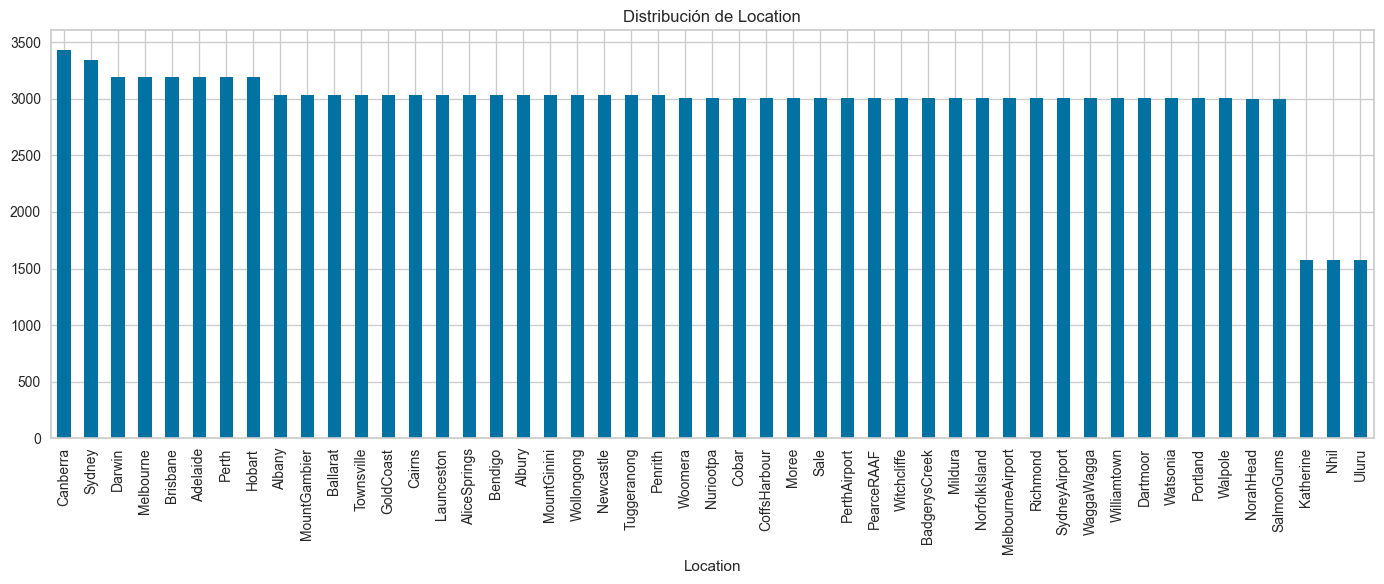

In [20]:
df['Location'].value_counts().plot(kind='bar', figsize=(14, 6))
plt.title("Distribución de Location")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [21]:
# Location se conserva en los datos crudos del modelo.
# La Region calculada arriba se usa solo para EDA; el modelo ajusta su propio
# KMeans dentro del subtrain de cada fold.


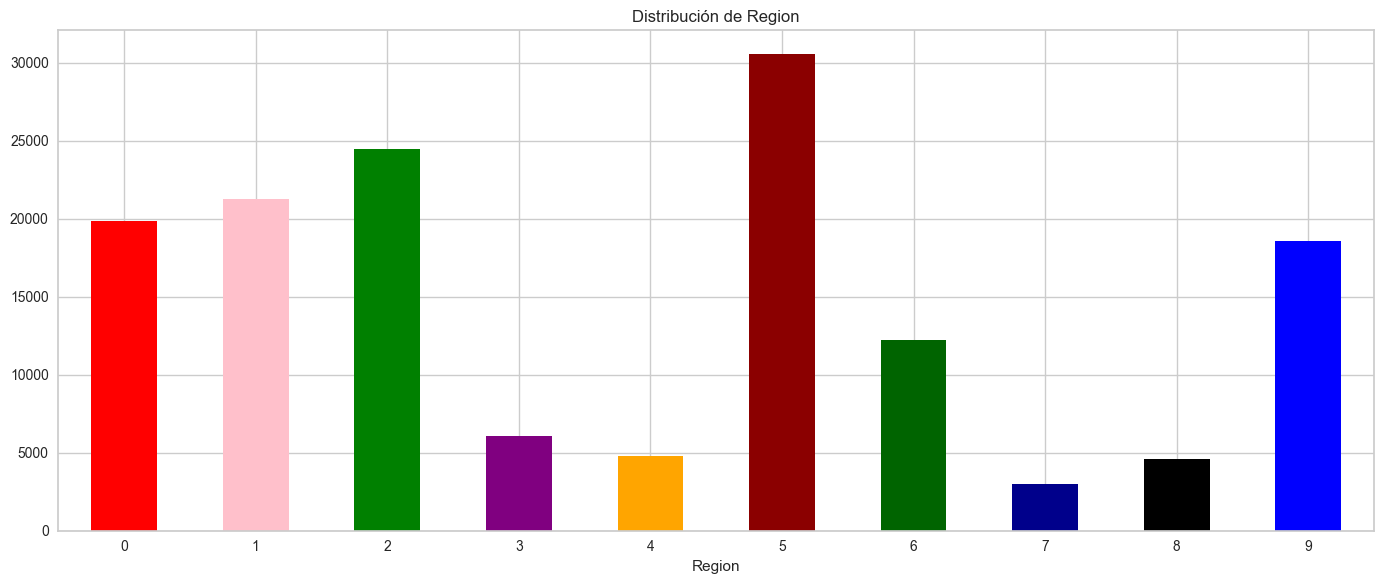

In [22]:
df['Region'].value_counts().sort_index().plot(kind='bar', figsize=(14, 6), color=colores)
plt.title("Distribución de Region")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [23]:
# revisamos los valores de la variable objetivo
df["RainTomorrow"].value_counts(dropna=False)

RainTomorrow
No     110281
Yes     31872
NaN      3259
Name: count, dtype: int64

In [24]:
# Calculamos la proporción de cada clase
df["RainTomorrow"].value_counts(normalize=True, dropna=False)

RainTomorrow
No     0.758404
Yes    0.219184
NaN    0.022412
Name: proportion, dtype: float64

In [25]:
# eliminamos filas donde la variable objetivo no tiene valor
df = df.dropna(subset=["RainTomorrow"])
# verificamos
df["RainTomorrow"].value_counts(dropna=False)

RainTomorrow
No     110281
Yes     31872
Name: count, dtype: int64

In [26]:
df_nuevo = df.copy()

In [27]:
# Separamos variables predictoras y objetivo.
# Region fue ajustada sobre todas las ubicaciones para EDA y no entra al modelo.
# El preprocesador fold-local parte de Date y Location crudas.
X = df_nuevo.drop(columns=["RainTomorrow", "Region"])
y = df_nuevo["RainTomorrow"]


In [28]:
# Separación aleatoria estratificada entre desarrollo y test.
# La comparación de modelos y la selección del threshold se realizan
# exclusivamente sobre el conjunto de desarrollo.
RANDOM_STATE = 42
FINAL_TEST_SIZE = 0.20
VALIDATION_SIZE_WITHIN_DEVELOPMENT = 0.20

EVALUATION_PROTOCOL = {
    "primary": {
        "name": "random_stratified",
        "purpose": "generalizacion entre observaciones meteorologicas historicas similares",
        "random_state": RANDOM_STATE,
        "development_fraction": 1 - FINAL_TEST_SIZE,
        "final_test_fraction": FINAL_TEST_SIZE,
        "validation_fraction_within_development": VALIDATION_SIZE_WITHIN_DEVELOPMENT,
    },
    "secondary": {
        "name": "temporal_robustness",
        "status": "implemented",
        "approach": "expanding_window_5fold",
        "decision_impact": "none",
        "threshold_source": "oof_selection",
        "purpose": "comparar robustez frente a observaciones cronologicamente posteriores",
    },
    "final_test_policy": {
        "status": "complete",
        "evaluation_count": 1,
        "result_artifact": "artifacts/final_test_metrics.json",
        "allowed": ["evaluate_selected_model_and_threshold_on_final_test"],
        "forbidden": [
            "model_selection",
            "hyperparameter_selection",
            "threshold_selection",
            "feature_selection",
        ],
    },
}

# 80% desarrollo / 20% test final.
X_development, X_test_final_raw, y_development, y_test_final = train_test_split(
    X,
    y,
    test_size=FINAL_TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y,
)

# Dentro de desarrollo: 80% entrenamiento / 20% validacion.
# Equivale aproximadamente a 64%/16%/20% sobre el total.
X_train, X_validation, y_train, y_validation = train_test_split(
    X_development,
    y_development,
    test_size=VALIDATION_SIZE_WITHIN_DEVELOPMENT,
    random_state=RANDOM_STATE,
    stratify=y_development,
)

# Manifiesto reproducible: una fila del CSV solo puede pertenecer a un split.
random_split_manifest = pd.concat([
    pd.Series("train", index=X_train.index, name="split"),
    pd.Series("validation", index=X_validation.index, name="split"),
    pd.Series("test_final", index=X_test_final_raw.index, name="split"),
]).sort_index()

random_split_manifest.to_csv("random_split_manifest.csv", index_label="row_index")

In [29]:
df_train = pd.concat([X_train, y_train], axis=1)
df_validation = pd.concat([X_validation, y_validation], axis=1)

# El conjunto de test se conserva sin transformar hasta la evaluación final.
df_test_final_raw = X_test_final_raw.copy()

In [30]:
# Comprobaciones estructurales del protocolo.
assert X_train.index.is_unique
assert X_validation.index.is_unique
assert X_test_final_raw.index.is_unique

assert set(X_train.index).isdisjoint(X_validation.index)
assert set(X_train.index).isdisjoint(X_test_final_raw.index)
assert set(X_validation.index).isdisjoint(X_test_final_raw.index)

assert len(random_split_manifest) == len(X)
assert random_split_manifest.index.is_unique
assert set(random_split_manifest.index) == set(X.index)

print("Train:", len(X_train))
print("Validation:", len(X_validation))
print("Test final:", len(X_test_final_raw))

Train: 90977
Validation: 22745
Test final: 28431


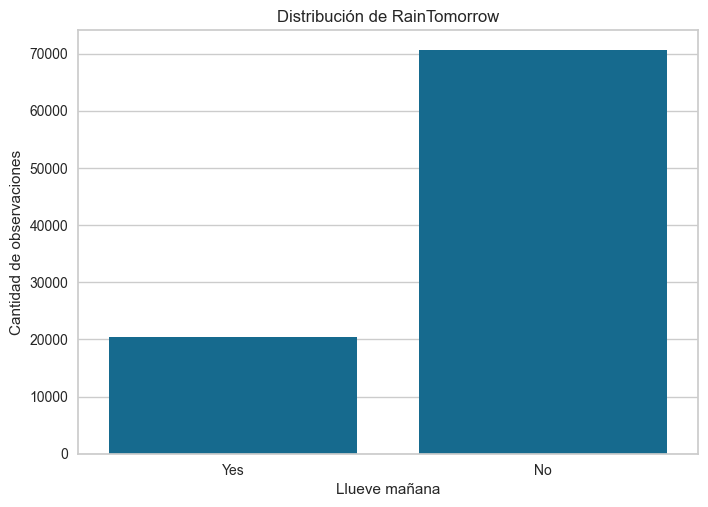

In [31]:
# Graficamos la distribución de la variable objetivo
sns.countplot(data=df_train,x="RainTomorrow", order=["Yes", "No"])
plt.title("Distribución de RainTomorrow")
plt.xlabel("Llueve mañana")
plt.ylabel("Cantidad de observaciones")
plt.show()

La variable objetivo es "RainTomorrow", que indica si llovió al día siguiente. La clase "No" aparece con mucha mayor frecuencia que la clase "Yes", por lo que el dataset está desbalanceado. Además de accuracy, será necesario analizar precision, recall y F1-score, especialmente para la clase positiva ("Yes"), ya que la accuracy por sí sola puede ocultar un desempeño deficiente en la detección de días lluviosos.

Las filas con valores faltantes en "RainTomorrow" se eliminan porque esta columna es la variable objetivo. Si no se conoce si al día siguiente llovió o no, esa observación no puede utilizarse para entrenar ni evaluar un modelo supervisado.

In [32]:
df_train.dtypes

Date              object
Location          object
MinTemp          float64
MaxTemp          float64
Rainfall         float64
Evaporation      float64
Sunshine         float64
WindGustDir       object
WindGustSpeed    float64
WindDir9am        object
WindDir3pm        object
WindSpeed9am     float64
WindSpeed3pm     float64
Humidity9am      float64
Humidity3pm      float64
Pressure9am      float64
Pressure3pm      float64
Cloud9am         float64
Cloud3pm         float64
Temp9am          float64
Temp3pm          float64
RainToday         object
RainTomorrow      object
dtype: object

In [33]:
# calculamos cantidad y porcentaje de valores faltantes por columna
faltantes = pd.DataFrame({
    "cantidad_faltantes": df_train.isna().sum(),
    "porcentaje_faltantes": df_train.isna().mean() * 100
})

faltantes = faltantes.sort_values(by="porcentaje_faltantes", ascending=False)

faltantes

,cantidad_faltantes,porcentaje_faltantes
Sunshine,43411,47.716456
Evaporation,38930,42.791035
Cloud3pm,36559,40.184882
Cloud9am,34287,37.687547
Pressure9am,8958,9.846445
Pressure3pm,8943,9.829957
WindDir9am,6454,7.094101
WindGustDir,5938,6.526924
WindGustSpeed,5899,6.484056
WindDir3pm,2470,2.714972


Algunas variables presentan un porcentaje elevado de valores faltantes. No se eliminan todas las filas incompletas porque eso implicaría perder una cantidad considerable de observaciones. En su lugar, la imputación se incorpora al pipeline de preprocesamiento y se ajusta dentro de cada fold de validación cruzada utilizando únicamente el subtrain correspondiente.

In [34]:
# identificamos variables numéricas y categóricas
columnas_numericas = df_train.select_dtypes(include=["int64", "float64"]).columns
columnas_categoricas = df_train.select_dtypes(include=["object","int32"]).columns

print("Variables numéricas:")
print(columnas_numericas)

print("\nVariables categóricas:")
print(columnas_categoricas)

Variables numéricas:
Index(['MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation', 'Sunshine',
       'WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am',
       'Humidity3pm', 'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm',
       'Temp9am', 'Temp3pm'],
      dtype='object')

Variables categóricas:
Index(['Date', 'Location', 'WindGustDir', 'WindDir9am', 'WindDir3pm',
       'RainToday', 'RainTomorrow'],
      dtype='object')


In [35]:
# obtenemos medidas descriptivas de las variables numéricas
df_train[columnas_numericas].describe().T

,count,mean,std,min,25%,50%,75%,max
MinTemp,90566.0,12.157416,6.430937,-9.7,7.6,12.0,16.8,32.1
MaxTemp,90787.0,23.200386,7.137008,-5.1,17.9,22.6,28.2,49.1
Rainfall,90070.0,2.352522,8.616204,0.0,0.0,0.0,0.6,371.0
Evaporation,52047.0,5.464613,4.170543,0.0,2.6,4.8,7.4,86.2
Sunshine,47566.0,7.629868,3.786196,0.0,4.9,8.5,10.7,14.5
WindGustSpeed,85078.0,39.943687,13.632149,6.0,31.0,38.0,47.0,135.0
WindSpeed9am,90113.0,14.013350,8.925787,0.0,7.0,13.0,19.0,88.0
WindSpeed3pm,89268.0,18.623505,8.856057,0.0,12.0,18.0,24.0,82.0
Humidity9am,89844.0,68.839760,19.109190,0.0,56.9,69.9,83.1,100.0
Humidity3pm,88659.0,51.530517,20.848860,0.0,36.6,51.9,65.7,100.0


Se calculan estadísticas descriptivas de las variables numéricas para identificar diferencias de escala.

In [36]:
# obtenemos un resumen de las variables categóricas.
df_train[columnas_categoricas].describe().T

,count,unique,top,freq
Date,90977,3380,2014-01-16,43
Location,90977,49,Canberra,2202
WindGustDir,85039,16,W,6334
WindDir9am,84523,16,N,7214
WindDir3pm,88507,16,SE,6882
RainToday,90070,2,No,70032
RainTomorrow,90977,2,No,70579


Para las variables categóricas interesa observar cuántas categorías distintas presentan y cuál es el valor más frecuente.

### Histogramas

In [37]:
df_train.columns

Index(['Date', 'Location', 'MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation',
       'Sunshine', 'WindGustDir', 'WindGustSpeed', 'WindDir9am', 'WindDir3pm',
       'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm',
       'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm', 'Temp9am',
       'Temp3pm', 'RainToday', 'RainTomorrow'],
      dtype='object')

In [38]:
len(df_train.columns)

23

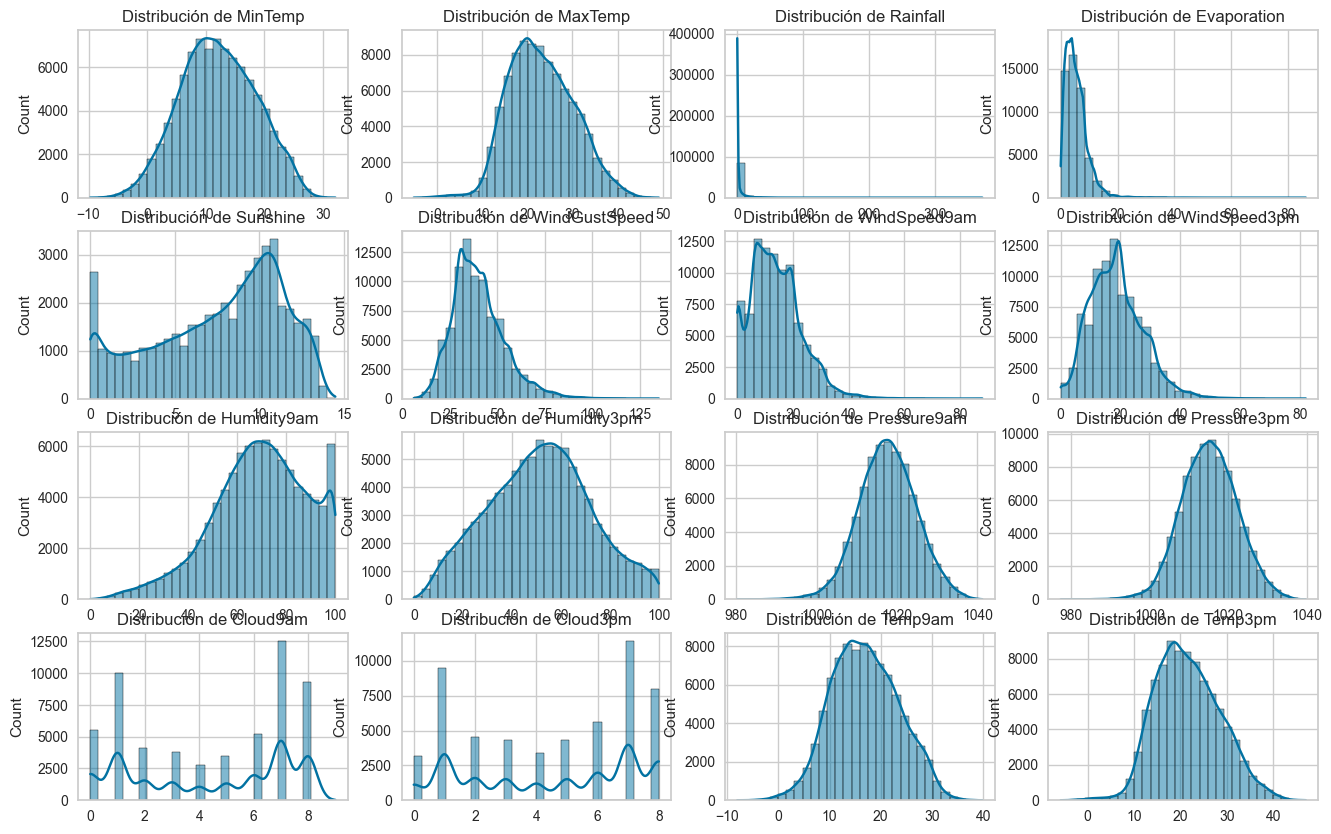

In [39]:
plt.figure(figsize=(16, 10))
for i, var in enumerate(columnas_numericas, 1):
    plt.subplot(4, 4, i)
    sns.histplot(df_train[var], kde=True, bins=30)
    plt.title(f"Distribución de {var}")
    plt.xlabel("")

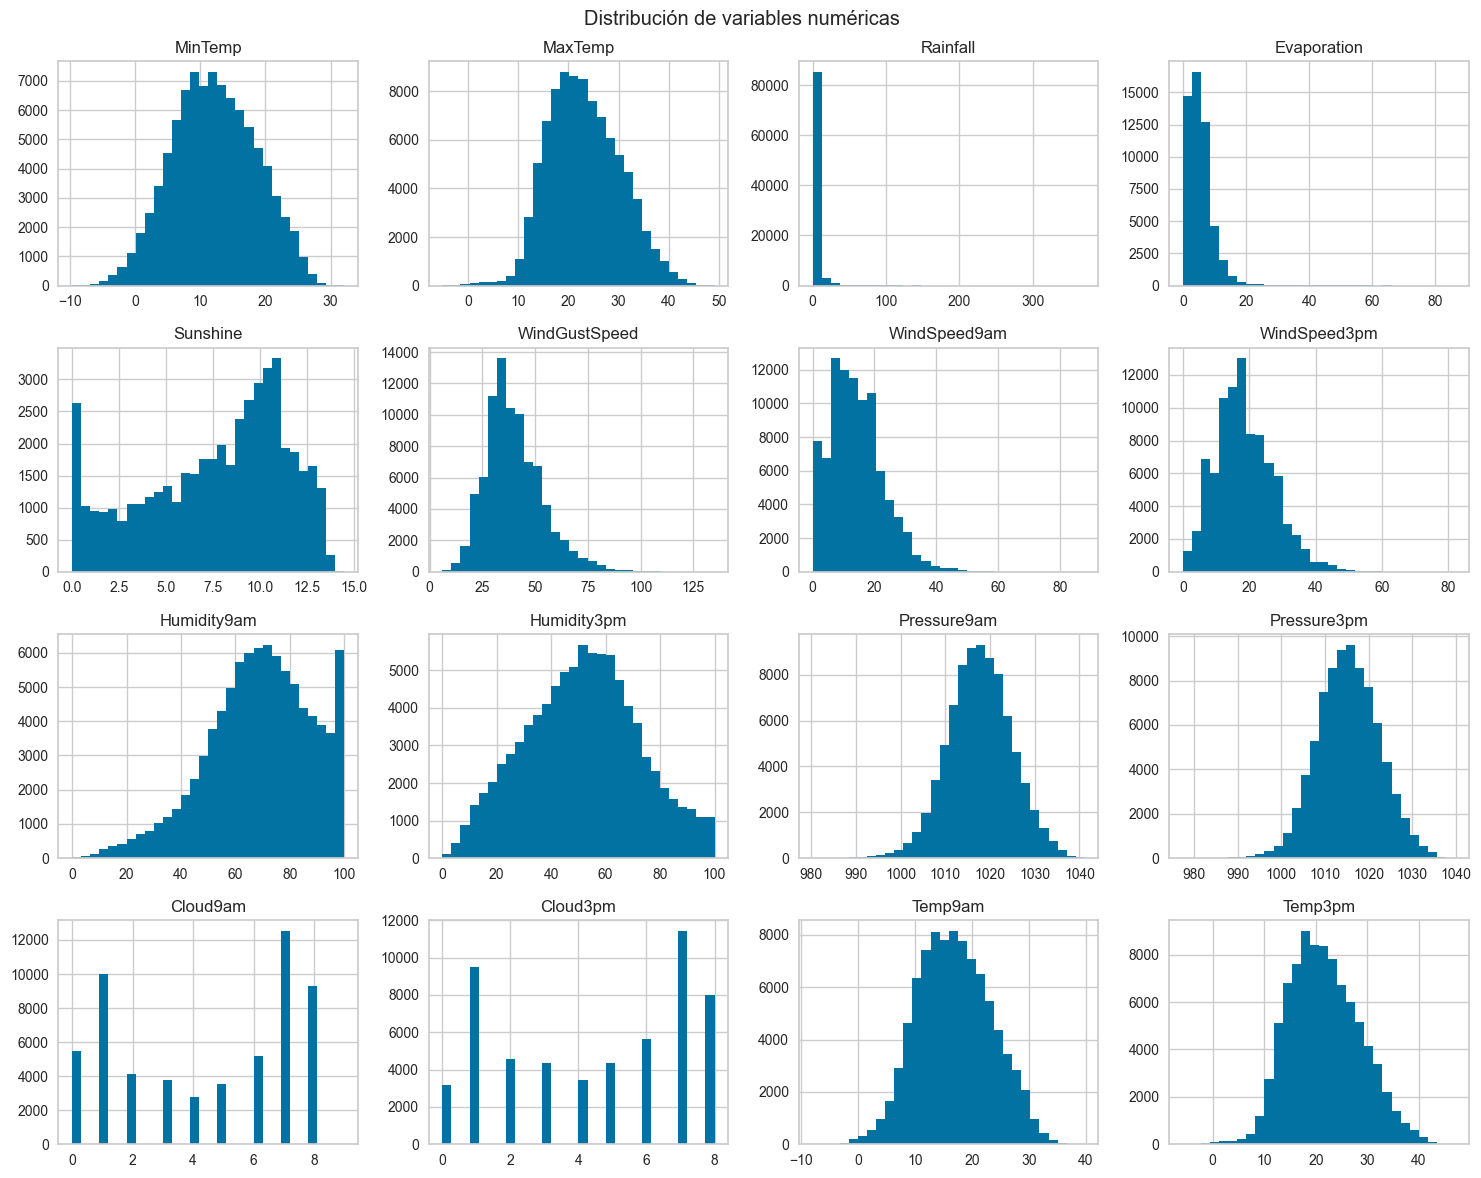

In [40]:
# graficamos histogramas para observar la distribución de las variables numéricas.
df_train[columnas_numericas].hist(figsize=(15, 12), bins=30)
plt.suptitle("Distribución de variables numéricas")
plt.tight_layout()
plt.show()

Se grafican histogramas de las variables numéricas para observar su distribución. Las variables no se encuentran en la misma escala: temperatura, presión, humedad, velocidad del viento y lluvia tienen unidades y rangos distintos. Por este motivo, el preprocesamiento incluye escalado.

### Boxplots

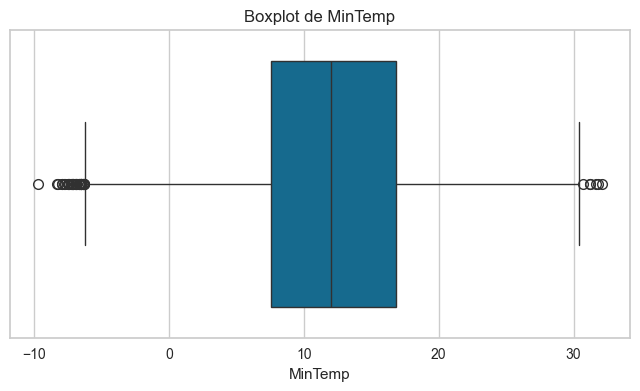

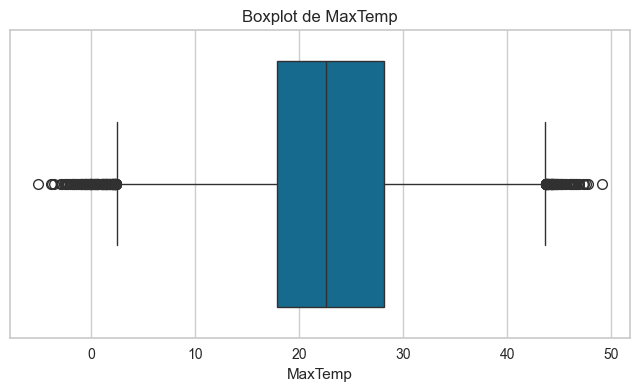

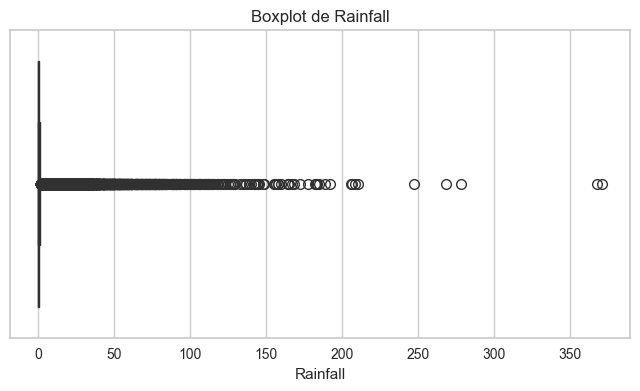

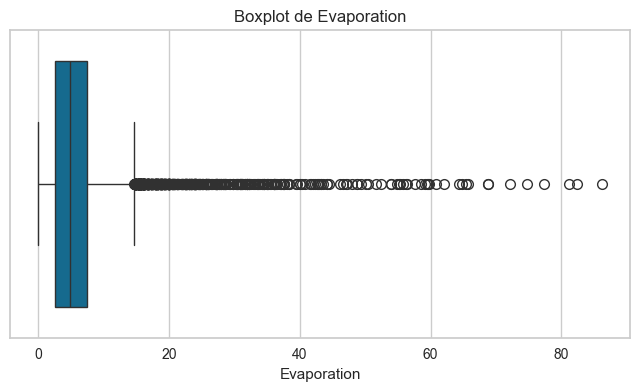

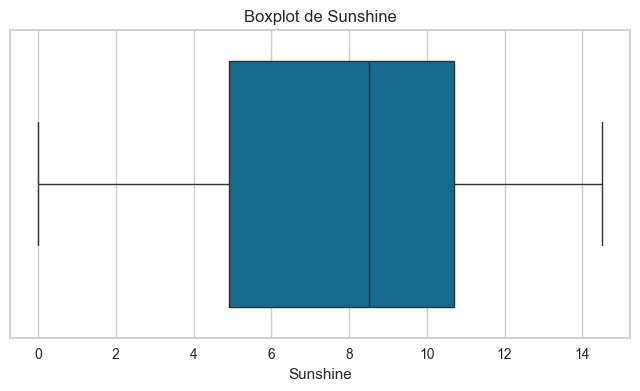

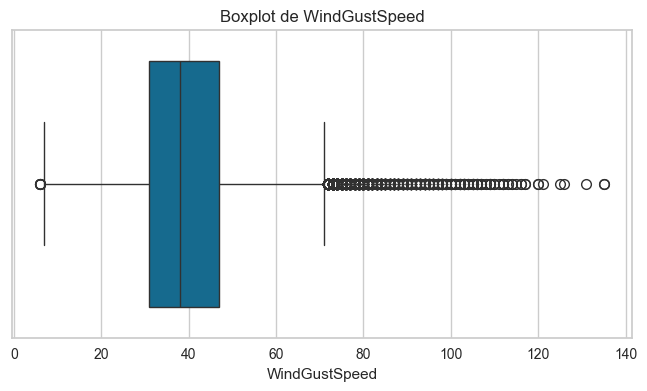

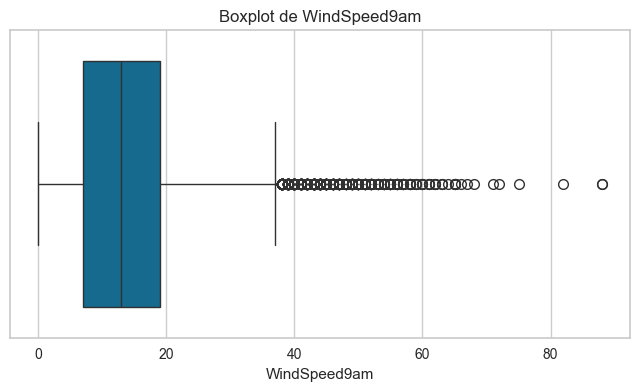

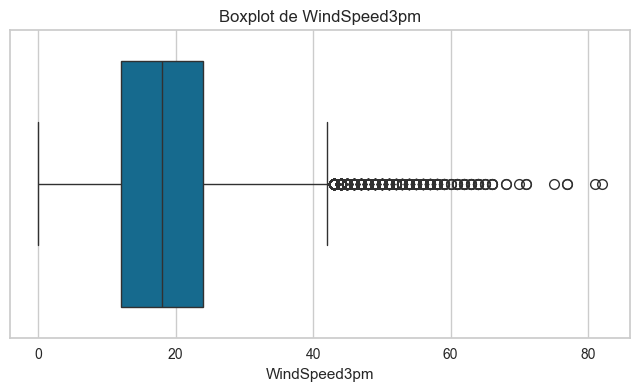

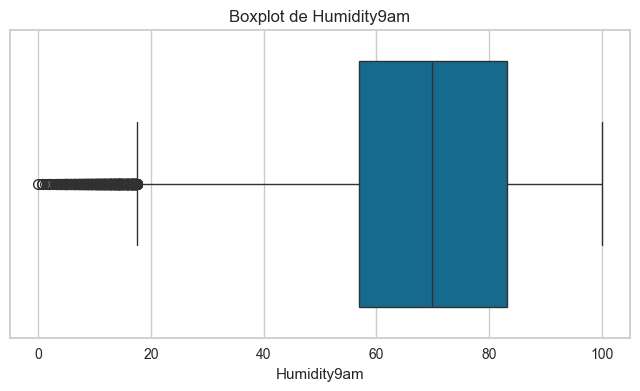

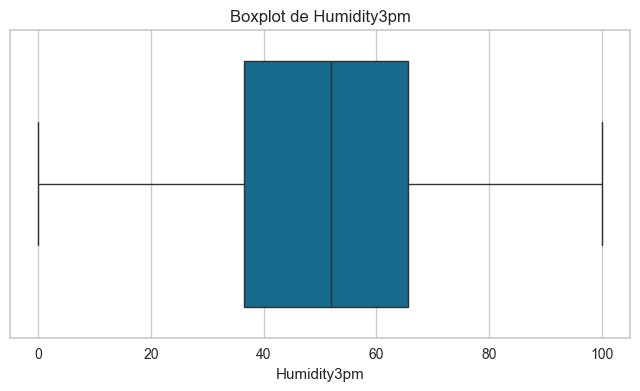

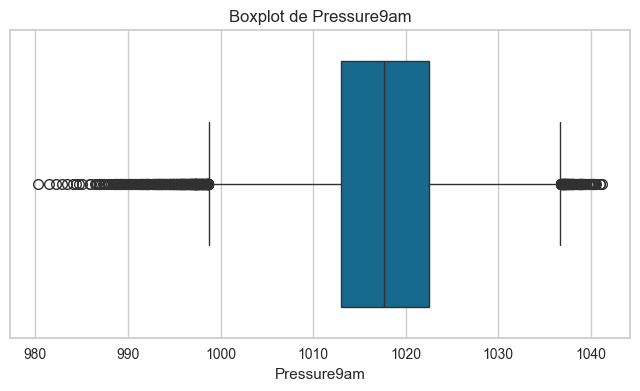

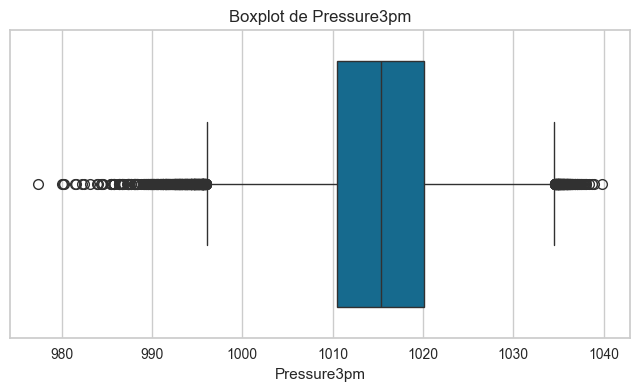

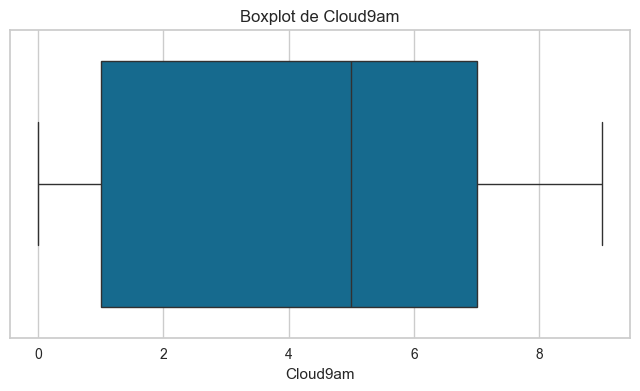

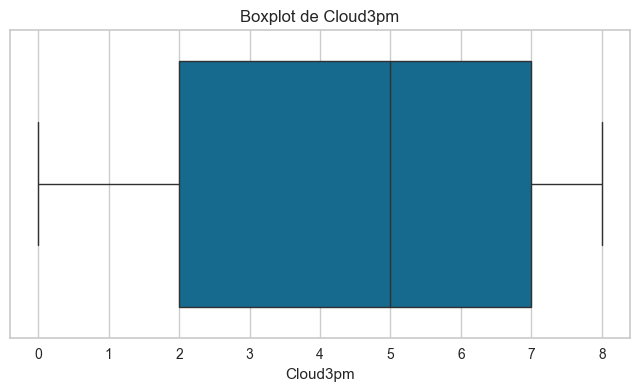

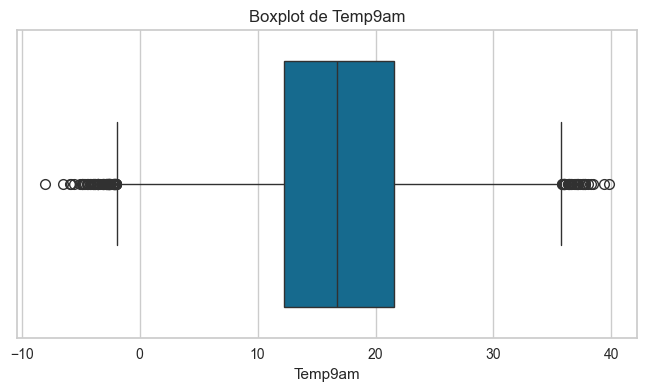

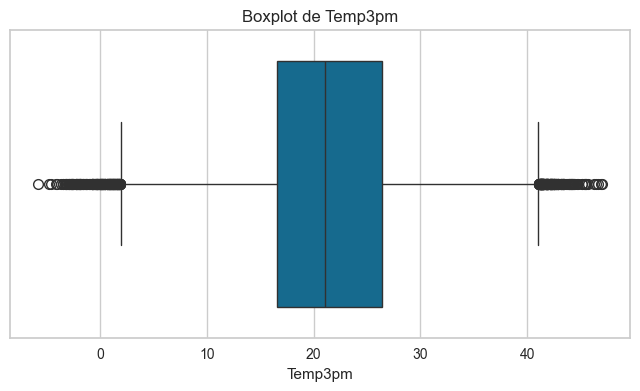

In [41]:
# Graficamos boxplots individuales para todas las variables numéricas.
for columna in columnas_numericas:
    plt.figure(figsize=(8, 4))
    sns.boxplot(data=df_train, x=columna)
    plt.title(f"Boxplot de {columna}")
    plt.xlabel(columna)
    plt.show()

In [42]:
# calculamos outliers por variable numérica usando el criterio del rango intercuartílico
resumen_outliers = []

for columna in columnas_numericas:
    q1 = df_train[columna].quantile(0.25)
    q3 = df_train[columna].quantile(0.75)
    iqr = q3 - q1

    limite_inferior = q1 - 1.5 * iqr
    limite_superior = q3 + 1.5 * iqr

    cantidad_outliers = ((df_train[columna] < limite_inferior) | (df_train[columna] > limite_superior)).sum()

    porcentaje_outliers = cantidad_outliers / df_train[columna].notna().sum() * 100

    resumen_outliers.append({
        "variable": columna,
        "limite_inferior": limite_inferior,
        "limite_superior": limite_superior,
        "cantidad_outliers": cantidad_outliers,
        "porcentaje_outliers": porcentaje_outliers
    })

resumen_outliers = pd.DataFrame(resumen_outliers)
resumen_outliers.sort_values(by="porcentaje_outliers", ascending=False)

,variable,limite_inferior,limite_superior,cantidad_outliers,porcentaje_outliers
2,Rainfall,-0.90,1.50,18195,20.200955
5,WindGustSpeed,7.00,71.00,2303,2.706928
3,Evaporation,-4.60,14.60,1233,2.369013
6,WindSpeed9am,-11.00,37.00,1222,1.356075
7,WindSpeed3pm,-6.00,42.00,1050,1.176233
8,Humidity9am,17.60,122.40,922,1.026223
10,Pressure9am,998.75,1036.75,757,0.922957
11,Pressure3pm,996.10,1034.50,590,0.719214
15,Temp3pm,1.90,41.10,472,0.529077
1,MaxTemp,2.45,43.65,305,0.335951


In [43]:
# verificamos si existen valores negativos en variables que no deberían ser negativas
variables_no_negativas = ["Rainfall", "Evaporation", "Sunshine","WindGustSpeed", "WindSpeed9am", "WindSpeed3pm","Humidity9am", "Humidity3pm","Pressure9am", "Pressure3pm", "Cloud9am", "Cloud3pm"]

valores_negativos = {}

for columna in variables_no_negativas:
    cantidad_negativos = (df_train[columna] < 0).sum()
    valores_negativos[columna] = cantidad_negativos

pd.Series(valores_negativos).sort_values(ascending=False)

Rainfall         0
Evaporation      0
Sunshine         0
WindGustSpeed    0
WindSpeed9am     0
WindSpeed3pm     0
Humidity9am      0
Humidity3pm      0
Pressure9am      0
Pressure3pm      0
Cloud9am         0
Cloud3pm         0
dtype: int64

In [44]:
# observamos los valores más frecuentes de Rainfall
df_train["Rainfall"].value_counts().head(20)

Rainfall
0.0    57810
0.2     5604
0.4     2402
0.6     1655
0.8     1302
1.0     1078
1.2      949
1.4      874
1.6      763
1.8      691
2.0      676
2.2      618
2.6      543
2.4      531
2.8      472
3.0      438
3.2      429
3.8      385
3.4      383
4.0      362
Name: count, dtype: int64

Analizamos posibles valores extremos utilizando el criterio del rango intercuartílico (IQR). Este criterio marca como posibles outliers los valores menores a Q1 - 1.5 * IQR o mayores a Q3 + 1.5 * IQR. Observamos también que una gran parte de las observaciones tiene lluvia igual o cercana a 0 mm. Esto hace que el rango intercuartílico sea bajo y que los valores de lluvia superiores a 1.5 mm sean marcados como outliers. Estos valores no necesariamente representan errores, sino que pueden ser días con mayor cantidad de lluvia.

### Matriz de correlación

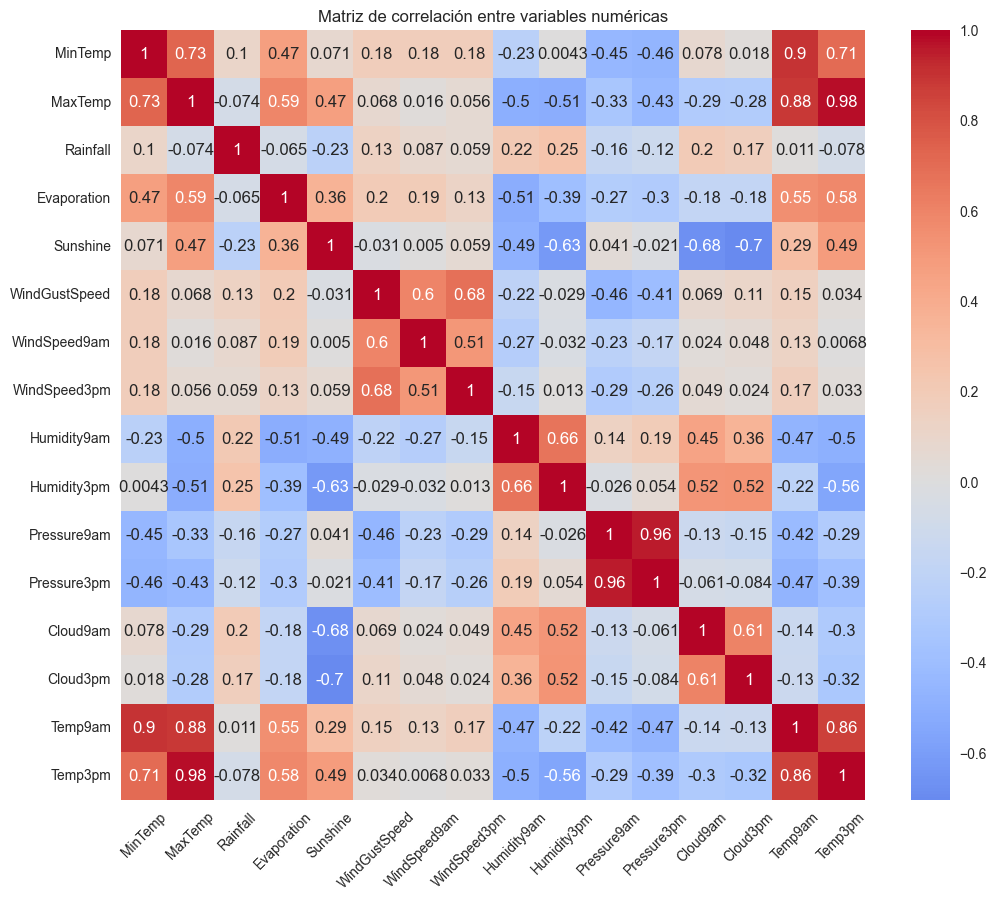

In [45]:
# calculamos la matriz de correlación entre variables numéricas
correlacion = df_train[columnas_numericas].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(correlacion, cmap="coolwarm", center=0, annot=True)
plt.title("Matriz de correlación entre variables numéricas")
plt.xticks(rotation=45)
plt.show()

Se identifican correlaciones positivas fuertes entre variables relacionadas con la temperatura, como "MaxTemp" y "Temp3pm", y entre variables de presión, como "Pressure9am" y "Pressure3pm". También se observan correlaciones negativas entre "Sunshine" y variables como "Cloud9am", "Cloud3pm" y "Humidity3pm", algo coherente con la relación entre nubosidad, humedad y horas de sol.
Esta matriz se utiliza como análisis exploratorio; en esta etapa no se eliminan variables automáticamente por su correlación.

In [46]:
df_train[columnas_categoricas].nunique()

Date            3380
Location          49
WindGustDir       16
WindDir9am        16
WindDir3pm        16
RainToday          2
RainTomorrow       2
dtype: int64

In [47]:
# Date -> Month se calcula en copias destinadas exclusivamente al EDA.
# Los conjuntos de modelado permanecen crudos para que el Pipeline controle el fit.
df_train_eda = df_train.copy()
df_validation_eda = df_validation.copy()
for frame_eda in (df_train_eda, df_validation_eda):
    frame_eda["Date"] = pd.to_datetime(frame_eda["Date"], errors="coerce")
    frame_eda["Month"] = frame_eda["Date"].dt.month


El mes se agrupa en la variable `Season`, reduciendo sus doce categorías a cuatro estaciones y, con ello, la dimensionalidad de la representación.

In [48]:
def asignar_estacion(mes):
    if mes in [12, 1, 2]:
        return "Summer"
    if mes in [3, 4, 5]:
        return "Autumn"
    if mes in [6, 7, 8]:
        return "Winter"
    if mes in [9, 10, 11]:
        return "Spring"
    return None

for frame_eda in (df_train_eda, df_validation_eda):
    frame_eda["Season"] = frame_eda["Month"].apply(asignar_estacion)


In [49]:
# X_train/X_validation conservan Date y Location sin transformar.
# y_train/y_validation mantienen exactamente los índices creados en el split.
assert {"Date", "Location"}.issubset(X_train.columns)
assert X_train.index.equals(y_train.index)
assert X_validation.index.equals(y_validation.index)


`Location` presenta muchas categorías porque identifica ciudades o estaciones meteorológicas. Para obtener una representación más compacta, las ubicaciones se agrupan en regiones geográficas.

La columna "Date" se convierte a formato fecha y se utiliza para extraer el mes de la observación. Esto permite representar la estacionalidad, ya que la probabilidad de lluvia puede variar según la época del año. Luego se elimina la fecha completa, porque codificar cada día como una categoría distinta generaría muchas columnas y no aportaría una representación simple para el modelo.

In [50]:
# codificamos la variable objetivo: No = 0, Yes = 1.
y_train = y_train.map({"No": 0, "Yes": 1})
y_validation = y_validation.map({"No": 0, "Yes": 1})

In [51]:
y_development_encoded = pd.concat([y_train, y_validation])

La variable objetivo se codifica como binaria: "No" se representa con 0 y "Yes" con 1, de modo que la clase positiva corresponda a los días en los que sí llueve.

In [52]:
# Esquema de salida del preprocesador (después de Date/Location -> Season/Region).
columnas_numericas = list(NUMERIC_COLUMNS)
columnas_categoricas = list(CATEGORICAL_COLUMNS)

print("Variables numéricas:")
print(columnas_numericas)
print("\nVariables categóricas:")
print(columnas_categoricas)


Variables numéricas:
['MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation', 'Sunshine', 'WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm', 'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm', 'Temp9am', 'Temp3pm']

Variables categóricas:
['WindGustDir', 'WindDir9am', 'WindDir3pm', 'RainToday', 'Season', 'Region']


Se vuelven a identificar las columnas numéricas y categóricas únicamente dentro de "X" para no incluir la variable objetivo dentro de las predictoras

In [53]:
# Verificamos proporciones solo dentro del conjunto de desarrollo.
# El target del test final no se inspecciona para tomar decisiones.
print("Proporcion en desarrollo:")
print(y_development_encoded.value_counts(normalize=True))

print("\nProporcion en entrenamiento:")
print(y_train.value_counts(normalize=True))

print("\nProporcion en validacion:")
print(y_validation.value_counts(normalize=True))

Proporcion en desarrollo:
RainTomorrow
0    0.775787
1    0.224213
Name: proportion, dtype: float64

Proporcion en entrenamiento:
RainTomorrow
0    0.775789
1    0.224211
Name: proportion, dtype: float64

Proporcion en validacion:
RainTomorrow
0    0.775775
1    0.224225
Name: proportion, dtype: float64


El protocolo principal utiliza una separación aleatoria estratificada para aprender patrones entre observaciones meteorológicas similares, aunque pertenezcan a años diferentes.

Se reserva el 20% de los datos como conjunto de test final y el 80% restante como conjunto de desarrollo. La comparación de modelos, el ajuste de hiperparámetros y la selección del threshold se realizan sobre desarrollo mediante validación cruzada estratificada de cinco folds y predicciones out-of-fold (OOF). El test se utiliza al final para estimar el desempeño del pipeline seleccionado sobre datos no utilizados durante el desarrollo.

Como análisis complementario, se realiza una evaluación temporal con cinco ventanas expansivas para estudiar la robustez frente a observaciones cronológicamente posteriores.

In [54]:
# Las coordenadas son metadatos externos; KMeans sí aprende y por eso se ajusta
# dentro de WeatherFeatureTransformer para cada fold.
location_coordinates = (
    df_coords.set_index("Location")[["Latitude", "Longitude"]]
    .apply(tuple, axis=1)
    .to_dict()
)

# Este estimador no se ajusta aquí. Cada modelo recibe un clon dentro de su Pipeline.
preprocesamiento = build_weather_preprocessor(
    location_coordinates=location_coordinates,
    random_state=RANDOM_STATE,
)

# Pipeline reducido para el modelo didáctico de una sola variable.
preprocesamiento_numerico = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])


### Imputación de datos

#### Variables numéricas

Las imputaciones por mediana de región o estación y por KNN están implementadas en `WeatherFeatureTransformer`. Sus tablas, el escalador y los imputadores se aprenden durante `fit`. Al formar parte del pipeline, cada fold ajusta una copia independiente con su subtrain y aplica únicamente `transform` sobre las observaciones de validación.


In [55]:
X_train.isnull().sum()


Date                 0
Location             0
MinTemp            411
MaxTemp            190
Rainfall           907
Evaporation      38930
Sunshine         43411
WindGustDir       5938
WindGustSpeed     5899
WindDir9am        6454
WindDir3pm        2470
WindSpeed9am       864
WindSpeed3pm      1709
Humidity9am       1133
Humidity3pm       2318
Pressure9am       8958
Pressure3pm       8943
Cloud9am         34287
Cloud3pm         36559
Temp9am            574
Temp3pm           1765
RainToday          907
dtype: int64

In [56]:
variables_mediana = list(MEDIAN_COLUMNS)
len(variables_mediana)


13

In [57]:
X_train.head()


,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday
57764,2016-06-30,Ballarat,4.6,7.5,0.2,NaN,NaN,W,63.0,N,...,24.0,99.6,100.0,1010.3,1006.8,8.0,7.0,5.2,5.9,No
31606,2012-02-09,Sydney,18.9,25.2,0.2,2.8,8.0,ENE,45.0,E,...,26.0,71.2,61.7,1013.9,1012.6,NaN,NaN,22.9,24.7,No
42226,2016-08-21,Williamtown,3.6,18.1,0.0,NaN,NaN,WNW,37.0,WNW,...,11.0,51.3,29.4,1021.3,1017.7,NaN,NaN,12.8,17.1,No
38451,2014-07-16,WaggaWagga,8.7,15.1,9.8,0.6,6.2,NW,30.0,WNW,...,19.0,95.4,65.8,1014.7,1014.2,8.0,4.0,9.0,14.1,Yes
33683,2009-06-23,SydneyAirport,10.2,20.1,0.4,1.6,9.5,NW,22.0,NW,...,10.0,72.9,57.5,1019.9,1016.4,1.0,1.0,13.7,19.1,No


In [58]:
# No se calculan medianas fuera del Pipeline.
print("Medianas Region/Season: fit fold-local dentro de WeatherFeatureTransformer")


Medianas Region/Season: fit fold-local dentro de WeatherFeatureTransformer


In [59]:
X_train.isnull().sum()


Date                 0
Location             0
MinTemp            411
MaxTemp            190
Rainfall           907
Evaporation      38930
Sunshine         43411
WindGustDir       5938
WindGustSpeed     5899
WindDir9am        6454
WindDir3pm        2470
WindSpeed9am       864
WindSpeed3pm      1709
Humidity9am       1133
Humidity3pm       2318
Pressure9am       8958
Pressure3pm       8943
Cloud9am         34287
Cloud3pm         36559
Temp9am            574
Temp3pm           1765
RainToday          907
dtype: int64

In [60]:
X_validation.isnull().sum()


Date                 0
Location             0
MinTemp            101
MaxTemp             62
Rainfall           233
Evaporation       9784
Sunshine         10915
WindGustDir       1505
WindGustSpeed     1495
WindDir9am        1604
WindDir3pm         603
WindSpeed9am       217
WindSpeed3pm       426
Humidity9am        294
Humidity3pm        598
Pressure9am       2333
Pressure3pm       2331
Cloud9am          8602
Cloud3pm          9140
Temp9am            153
Temp3pm            441
RainToday          233
dtype: int64

#### Imputación mediante KNN

##### Escalado de datos

Como KNN es un método basado en distancias, es necesario escalar los datos antes de utilizarlo para imputar. De lo contrario, las variables con valores grandes podrían dominar el cálculo de la distancia y afectar la imputación.

In [61]:
# El StandardScaler usado por KNN y el escalado final se ajustan dentro
# del preprocesador clonado por cada fold; aquí no se ejecuta ningún fit.
print("Escalado: fit fold-local dentro del Pipeline")


Escalado: fit fold-local dentro del Pipeline


##### KNN

In [62]:
# Variables imputadas con KNN por región y estación.
variables_knn = list(KNN_COLUMNS)


In [63]:
# No se ajustan KNNImputer globales ni por grupo fuera del Pipeline.
print("KNNImputer: fit fold-local dentro de WeatherFeatureTransformer")


KNNImputer: fit fold-local dentro de WeatherFeatureTransformer


In [64]:
X_train.isnull().sum()


Date                 0
Location             0
MinTemp            411
MaxTemp            190
Rainfall           907
Evaporation      38930
Sunshine         43411
WindGustDir       5938
WindGustSpeed     5899
WindDir9am        6454
WindDir3pm        2470
WindSpeed9am       864
WindSpeed3pm      1709
Humidity9am       1133
Humidity3pm       2318
Pressure9am       8958
Pressure3pm       8943
Cloud9am         34287
Cloud3pm         36559
Temp9am            574
Temp3pm           1765
RainToday          907
dtype: int64

In [65]:
X_train.head()


,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday
57764,2016-06-30,Ballarat,4.6,7.5,0.2,NaN,NaN,W,63.0,N,...,24.0,99.6,100.0,1010.3,1006.8,8.0,7.0,5.2,5.9,No
31606,2012-02-09,Sydney,18.9,25.2,0.2,2.8,8.0,ENE,45.0,E,...,26.0,71.2,61.7,1013.9,1012.6,NaN,NaN,22.9,24.7,No
42226,2016-08-21,Williamtown,3.6,18.1,0.0,NaN,NaN,WNW,37.0,WNW,...,11.0,51.3,29.4,1021.3,1017.7,NaN,NaN,12.8,17.1,No
38451,2014-07-16,WaggaWagga,8.7,15.1,9.8,0.6,6.2,NW,30.0,WNW,...,19.0,95.4,65.8,1014.7,1014.2,8.0,4.0,9.0,14.1,Yes
33683,2009-06-23,SydneyAirport,10.2,20.1,0.4,1.6,9.5,NW,22.0,NW,...,10.0,72.9,57.5,1019.9,1016.4,1.0,1.0,13.7,19.1,No


In [66]:
# La inspección antes/después se realizará al reejecutar con un
# preprocesador ajustado para análisis, sin reutilizarlo en validación cruzada.


In [67]:
X_train.head()


,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday
57764,2016-06-30,Ballarat,4.6,7.5,0.2,NaN,NaN,W,63.0,N,...,24.0,99.6,100.0,1010.3,1006.8,8.0,7.0,5.2,5.9,No
31606,2012-02-09,Sydney,18.9,25.2,0.2,2.8,8.0,ENE,45.0,E,...,26.0,71.2,61.7,1013.9,1012.6,NaN,NaN,22.9,24.7,No
42226,2016-08-21,Williamtown,3.6,18.1,0.0,NaN,NaN,WNW,37.0,WNW,...,11.0,51.3,29.4,1021.3,1017.7,NaN,NaN,12.8,17.1,No
38451,2014-07-16,WaggaWagga,8.7,15.1,9.8,0.6,6.2,NW,30.0,WNW,...,19.0,95.4,65.8,1014.7,1014.2,8.0,4.0,9.0,14.1,Yes
33683,2009-06-23,SydneyAirport,10.2,20.1,0.4,1.6,9.5,NW,22.0,NW,...,10.0,72.9,57.5,1019.9,1016.4,1.0,1.0,13.7,19.1,No


In [68]:
print("Visualización de imputaciones pendiente de la reejecución del protocolo fold-local")


Visualización de imputaciones pendiente de la reejecución del protocolo fold-local


El pipeline completo contiene la ingeniería de variables meteorológicas, las imputaciones, la codificación one-hot y el escalado. En cada fold, scikit-learn clona el estimador y ajusta el preprocesamiento utilizando solamente el subtrain correspondiente, lo que evita que la validación aporte información al ajuste de las transformaciones.


#### Variables categóricas

In [69]:
variables_categoricas_imputar = list(MODE_COLUMNS)
print("Modas Region/Season: fit fold-local dentro de WeatherFeatureTransformer")


Modas Region/Season: fit fold-local dentro de WeatherFeatureTransformer


In [70]:
print(X_train.isnull().sum())

Date                 0
Location             0
MinTemp            411
MaxTemp            190
Rainfall           907
Evaporation      38930
Sunshine         43411
WindGustDir       5938
WindGustSpeed     5899
WindDir9am        6454
WindDir3pm        2470
WindSpeed9am       864
WindSpeed3pm      1709
Humidity9am       1133
Humidity3pm       2318
Pressure9am       8958
Pressure3pm       8943
Cloud9am         34287
Cloud3pm         36559
Temp9am            574
Temp3pm           1765
RainToday          907
dtype: int64


## Ítem 2: Regresión logística

In [71]:
round(y_train.value_counts(normalize=True) * 100, 2)
#round(y_validation.value_counts(normalize=True) * 100, 2)

RainTomorrow
0    77.58
1    22.42
Name: proportion, dtype: float64

Como el dataset está desbalanceado, se utiliza `class_weight="balanced"` para asignar mayor peso a la clase minoritaria durante el entrenamiento.

In [72]:
f1_comparacion_modelos = {}
accuracy_comparacion_modelos = {}
recall_comparacion_modelos = {}

In [73]:
# Pipeline completo: el fit de toda transformación aprendida recibe solo train.
modelo_logistico = Pipeline(steps=[
    ("preprocesamiento", clone(preprocesamiento)),
    ("clasificador", LogisticRegression(
        max_iter=1000,
        random_state=RANDOM_STATE,
        class_weight="balanced",
    )),
])


In [74]:
# Dataframe con el que entrenaremos al modelo
X_train

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday
57764,2016-06-30,Ballarat,4.6,7.5,0.2,NaN,NaN,W,63.0,N,...,24.0,99.6,100.0,1010.3,1006.8,8.0,7.0,5.2,5.9,No
31606,2012-02-09,Sydney,18.9,25.2,0.2,2.8,8.0,ENE,45.0,E,...,26.0,71.2,61.7,1013.9,1012.6,NaN,NaN,22.9,24.7,No
42226,2016-08-21,Williamtown,3.6,18.1,0.0,NaN,NaN,WNW,37.0,WNW,...,11.0,51.3,29.4,1021.3,1017.7,NaN,NaN,12.8,17.1,No
38451,2014-07-16,WaggaWagga,8.7,15.1,9.8,0.6,6.2,NW,30.0,WNW,...,19.0,95.4,65.8,1014.7,1014.2,8.0,4.0,9.0,14.1,Yes
33683,2009-06-23,SydneyAirport,10.2,20.1,0.4,1.6,9.5,NW,22.0,NW,...,10.0,72.9,57.5,1019.9,1016.4,1.0,1.0,13.7,19.1,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
144810,2015-11-01,Uluru,22.6,40.1,0.0,NaN,NaN,E,41.0,ESE,...,19.0,13.2,9.1,1011.9,1006.8,NaN,NaN,32.9,37.9,No
37568,2011-12-17,WaggaWagga,15.2,28.9,0.0,8.0,12.6,ENE,43.0,ENE,...,13.0,50.9,33.8,1020.4,1016.3,6.0,5.0,20.4,28.3,No
63684,2016-02-24,Sale,20.9,32.1,0.2,NaN,NaN,S,42.0,W,...,29.0,68.1,56.2,1010.5,1009.2,8.0,NaN,23.9,26.9,No
44521,2014-08-08,Wollongong,10.3,16.5,0.0,NaN,NaN,ENE,21.0,SSW,...,11.0,84.8,76.0,1031.9,1029.8,7.0,2.0,13.7,15.4,No


In [75]:
# entrenamos el modelo utilizando el conjunto de entrenamiento
modelo_logistico.fit(X_train, y_train)

Pipeline(steps=[('preprocesamiento',
                 Pipeline(steps=[('weather_features',
                                  WeatherFeatureTransformer(location_coordinates={'Adelaide': (-34.9281805,
                                                                                               138.5999312),
                                                                                  'Albany': (-35.0247822,
                                                                                             117.883608),
                                                                                  'Albury': (-36.0737734,
                                                                                             146.9135265),
                                                                                  'AliceSprings': (-23.6983884,
                                                                                                   133.8812885),
                                                                                  'BadgerysCreek': (-33.8831452,
                                                                                                    150.742466),
                                                                                  'Ballarat': (-37.5623013,
                                                                                               143.8605645),
                                                                                  'Bend...
                                                                   Pipeline(steps=(('fallback_imputer',
                                                                                    SimpleImputer(keep_empty_features=True,
                                                                                                  strategy='most_frequent')),
                                                                                   ('encoder',
                                                                                    OneHotEncoder(handle_unknown='ignore',
                                                                                                  sparse_output=False)))),
                                                                   ['WindGustDir',
                                                                    'WindDir9am',
                                                                    'WindDir3pm',
                                                                    'RainToday',
                                                                    'Season',
                                                                    'Region'])),
                                                    verbose_feature_names_out=False))])),
                ('clasificador',
                 LogisticRegression(class_weight='balanced', max_iter=1000,
                                    random_state=42))])

In [76]:
# obtenemos las predicciones de clase sobre el conjunto de validacion
y_pred_logistico = modelo_logistico.predict(X_validation)

In [77]:
# obtenemos las probabilidades de pertenecer a la clase positiva
y_proba_logistico = modelo_logistico.predict_proba(X_validation)[:, 1]

In [78]:
# observamos las primeras predicciones de clase
y_pred_logistico[:10]

array([1, 0, 1, 0, 1, 0, 0, 1, 0, 0], dtype=int64)

In [79]:
# observamos las primeras probabilidades estimadas de lluvia
y_proba_logistico[:10]

array([0.8158481 , 0.30185037, 0.97019987, 0.23507543, 0.89137911,
       0.49284841, 0.24831048, 0.50422388, 0.10571328, 0.29464218])

In [80]:
y_validation[:10]

122329    1
15278     0
76430     1
26289     0
43208     0
102245    0
31611     0
23315     1
66012     0
28166     0
Name: RainTomorrow, dtype: int64

In [81]:
# calculamos métricas principales para evaluar el modelo de regresión logística
accuracy_logistico = accuracy_score(y_validation, y_pred_logistico)
precision_logistico = precision_score(y_validation, y_pred_logistico)
recall_logistico = recall_score(y_validation, y_pred_logistico)
f1_logistico = f1_score(y_validation, y_pred_logistico)
auc_logistico = roc_auc_score(y_validation, y_proba_logistico)

print("Accuracy:", accuracy_logistico)
print("Precision:", precision_logistico)
print("Recall:", recall_logistico)
print("F1-score:", f1_logistico)
print("ROC-AUC:", auc_logistico)

Accuracy: 0.7874258078698615
Precision: 0.5172413793103449
Recall: 0.7794117647058824
F1-score: 0.6218224481814627
ROC-AUC: 0.8670951666583324


Se calculan distintas métricas porque el dataset está desbalanceado. En este caso, la accuracy por sí sola puede ser insuficiente, ya que un modelo podría acertar muchos casos de la clase mayoritaria (No) y aun así detectar mal los casos de lluvia (Yes). Por este motivo, también se analizan precision, recall, F1-score y ROC-AUC. La clase positiva corresponde a "RainTomorrow = Yes", es decir, los días en los que sí llueve al día siguiente.

Con el umbral por defecto de 0.5, si la probabilidad es mayor o igual a 0.5 el modelo predice lluvia; si es menor, predice que no llueve. Con este umbral, el modelo obtuvo accuracy 0.7874, precision 0.5172, recall 0.7794 y F1-score 0.6218. El recall indica que detecta cerca del 78% de los días lluviosos, aunque con una cantidad apreciable de falsas alarmas.

### Matriz de confusión

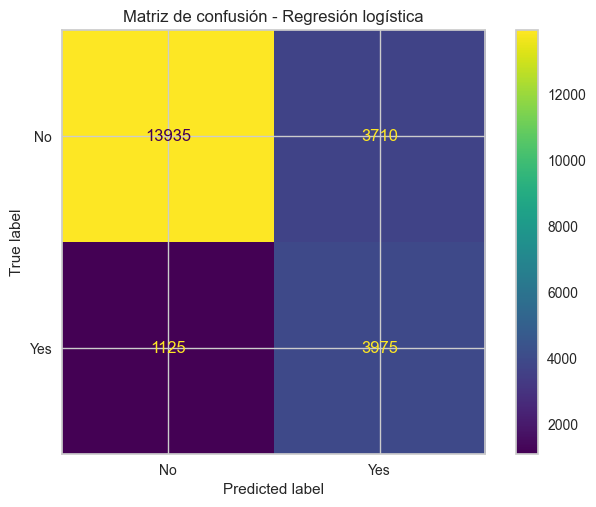

In [82]:
# graficamos la matriz de confusión para la regresión logística
cm_logistico = confusion_matrix(y_validation, y_pred_logistico)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_logistico,display_labels=["No", "Yes"])

disp.plot()
plt.title("Matriz de confusión - Regresión logística")
plt.show()

In [83]:
# extraemos los valores de la matriz de confusión
vn, fp, fn, vp = cm_logistico.ravel()

print("Verdaderos negativos:", vn)
print("Falsos positivos:", fp)
print("Falsos negativos:", fn)
print("Verdaderos positivos:", vp)

Verdaderos negativos: 13935
Falsos positivos: 3710
Falsos negativos: 1125
Verdaderos positivos: 3975


La matriz de confusión muestra 13935 verdaderos negativos y 3975 verdaderos positivos.

También se observan 1125 falsos negativos, es decir, días en los que realmente llovió pero el modelo predijo que no llovería.

Los 3710 falsos positivos corresponden a días en los que el modelo predijo lluvia pero finalmente no llovió. En este problema, los falsos positivos representan falsas alarmas, mientras que los falsos negativos representan lluvias no detectadas.

La matriz confirma el comportamiento de las métricas: el balanceo favorece la detección de la clase "Yes", con recall alto, a costa de incrementar los falsos positivos.

### Curva ROC y AUC

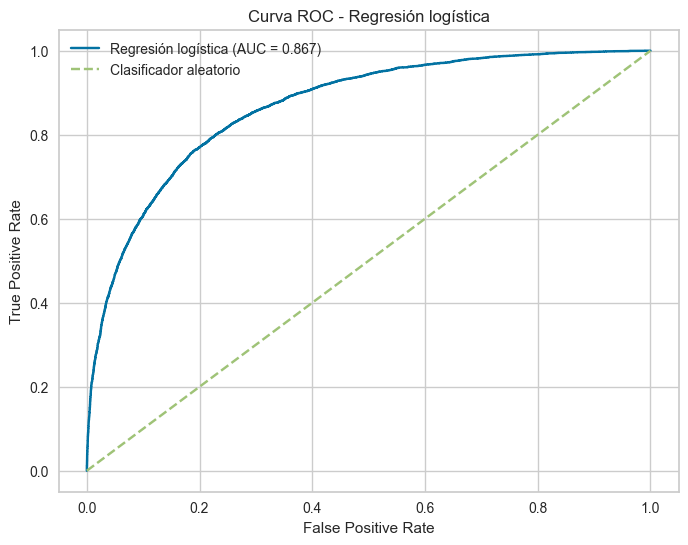

In [84]:
# Calculamos la curva ROC para la regresión logística.
fpr_logistico, tpr_logistico, thresholds_logistico = roc_curve(y_validation,y_proba_logistico)

plt.figure(figsize=(8, 6))
plt.plot(fpr_logistico,tpr_logistico,label=f"Regresión logística (AUC = {auc_logistico:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", label="Clasificador aleatorio")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC - Regresión logística")
plt.legend()
plt.show()

El ROC-AUC fue de 0.8671, lo que indica que las probabilidades del modelo separan razonablemente bien los casos de lluvia y no lluvia. Esta métrica evalúa el ordenamiento de las probabilidades a través de todos los umbrales y complementa las métricas calculadas con el threshold 0.5.

### Análisis diagnóstico del umbral 0.5

In [85]:
# Diagnóstico descriptivo a threshold fijo. No se optimiza con validation.
# El único threshold seleccionable se obtiene luego de probabilidades OOF.
umbral_diagnostico = 0.5
print("Umbral diagnóstico fijo:", umbral_diagnostico)

Umbral diagnóstico fijo: 0.5


In [86]:
# Predicciones exploratorias para analizar el efecto de este umbral.
y_pred_logistico_umbral = (y_proba_logistico >= umbral_diagnostico).astype(int)

print(classification_report(y_validation, y_pred_logistico_umbral))

              precision    recall  f1-score   support

           0       0.93      0.79      0.85     17645
           1       0.52      0.78      0.62      5100

    accuracy                           0.79     22745
   macro avg       0.72      0.78      0.74     22745
weighted avg       0.83      0.79      0.80     22745



In [87]:
metricas_diagnosticas_umbral_fijo = {
    "f1_positive": f1_score(y_validation, y_pred_logistico_umbral, pos_label=1),
    "precision": precision_score(y_validation, y_pred_logistico_umbral, pos_label=1),
    "recall": recall_score(y_validation, y_pred_logistico_umbral, pos_label=1),
}
metricas_diagnosticas_umbral_fijo

{'f1_positive': 0.6218224481814627,
 'precision': 0.5172413793103449,
 'recall': 0.7794117647058824}

In [88]:
f1_comparacion_modelos
#accuracy_comparacion_modelos

{}

El diagnóstico reproduce el umbral por defecto de 0.5 y, por lo tanto, coincide con la evaluación anterior: F1 positivo 0.6218, precision 0.5172 y recall 0.7794. Esta referencia permite observar el equilibrio entre lluvias detectadas y falsas alarmas sin realizar una búsqueda de threshold sobre validation.

La selección del threshold utilizada por el modelo final se realiza posteriormente con probabilidades OOF y F1 positivo como criterio principal.

## Ítem 3: Implementación de modelo base

In [89]:
# Modelo base con el mismo contrato train/transform que el resto.
modelo_base = Pipeline(steps=[
    ("preprocesamiento", clone(preprocesamiento)),
    ("clasificador", DummyClassifier(strategy="most_frequent", random_state=RANDOM_STATE)),
])

modelo_base.fit(X_train, y_train)
y_pred_base = modelo_base.predict(X_validation)


In [90]:
# calculamos métricas principales para evaluar el modelo base basado en frecuencia
accuracy_base = accuracy_score(y_validation, y_pred_base)
precision_base = precision_score(y_validation, y_pred_base, zero_division=0)
recall_base = recall_score(y_validation, y_pred_base, zero_division=0)
f1_base = f1_score(y_validation, y_pred_base, zero_division=0)
auc_base = roc_auc_score(y_validation, y_pred_base)

print("Accuracy:", accuracy_base)
print("Precision:", precision_base)
print("Recall:", recall_base)
print("F1-score:", f1_base)
print("ROC-AUC:", auc_base)

Accuracy: 0.7757748955814465
Precision: 0.0
Recall: 0.0
F1-score: 0.0
ROC-AUC: 0.5


In [91]:
f1_modelo_base_dummy = f1_score(y_validation, y_pred_base, pos_label=1)
f1_comparacion_modelos["Modelo_base_dummy"] = f1_modelo_base_dummy
accuracy_comparacion_modelos["Modelo_base_dummy"] = accuracy_score(y_validation, y_pred_base)
recall_comparacion_modelos["Modelo_base_dummy"] = recall_score(y_validation, y_pred_base, pos_label=1)

In [92]:
#accuracy_comparacion_modelos

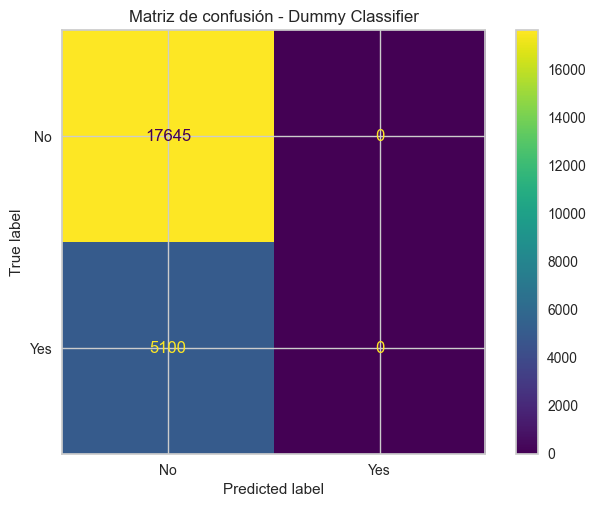

In [93]:
# graficamos la matriz de confusión para la regresión logística
cm_base = confusion_matrix(y_validation, y_pred_base)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_base,display_labels=["No", "Yes"])

disp.plot()
plt.title("Matriz de confusión - Dummy Classifier")
plt.show()

In [94]:
# extraemos los valores de la matriz de confusión
vn, fp, fn, vp = cm_base.ravel()

print("Verdaderos negativos:", vn)
print("Falsos positivos:", fp)
print("Falsos negativos:", fn)
print("Verdaderos positivos:", vp)

Verdaderos negativos: 17645
Falsos positivos: 0
Falsos negativos: 5100
Verdaderos positivos: 0


La matriz de confusión del modelo base muestra que el clasificador predice siempre la clase mayoritaria, es decir, No. Por eso clasifica correctamente los días sin lluvia, pero no detecta ningún caso de lluvia.
Esto confirma que la accuracy no alcanza para evaluar este problema, ya que un modelo puede obtener un valor aparentemente aceptable simplemente prediciendo siempre la clase más frecuente.

### Modelo base: si llovió hoy, llueve mañana

In [95]:

df_rain_train = X_train[["RainToday"]].copy()
df_rain_train["RainTomorrow"] = y_train.map({0: "No", 1: "Yes"})

# eliminamos filas donde RainToday sea nulo para observar la relación de forma directa
df_rain_train = df_rain_train.dropna(subset=["RainToday"])

tabla_rain_pct = pd.crosstab(
    df_rain_train["RainToday"],
    df_rain_train["RainTomorrow"],
    normalize="index"
) * 100

tabla_rain_pct = tabla_rain_pct.reindex(columns=["No", "Yes"])
tabla_rain_pct.round(2)

RainTomorrow,No,Yes
RainToday,,
No,84.85,15.15
Yes,53.31,46.69


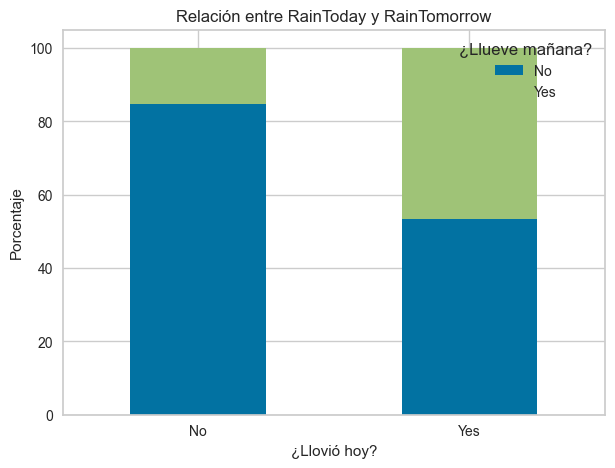

In [96]:
tabla_rain_pct.plot(kind="bar", stacked=True, figsize=(7, 5))

plt.title("Relación entre RainToday y RainTomorrow")
plt.xlabel("¿Llovió hoy?")
plt.ylabel("Porcentaje")
plt.xticks(rotation=0)
plt.legend(title="¿Llueve mañana?")
plt.show()

En este caso se observa que:

- Cuando no llueve durante el día, es muy probable que tampoco llueva al día siguiente.
- Incluso entre los días con lluvia, en la mayoría de los casos no vuelve a llover al día siguiente.

A diferencia del baseline que siempre predice "No", este modelo identifica algunos casos positivos utilizando `RainToday`.

In [97]:
# implementamos un modelo base basado en una regla simple:
# si RainToday = Yes, predecimos RainTomorrow = Yes; si RainToday = No, predecimos RainTomorrow = No

moda_raintoday_train = X_train["RainToday"].mode()[0]

y_pred_base_raintoday = (
    X_validation["RainToday"]
    .fillna(moda_raintoday_train)
    .map({"No": 0, "Yes": 1})
    .astype(int)
)

In [98]:
# calculamos métricas principales para evaluar el modelo base basado en RainToday
accuracy_base_raintoday = accuracy_score(y_validation, y_pred_base_raintoday)
precision_base_raintoday = precision_score(y_validation, y_pred_base_raintoday, zero_division=0)
recall_base_raintoday = recall_score(y_validation, y_pred_base_raintoday, zero_division=0)
f1_base_raintoday = f1_score(y_validation, y_pred_base_raintoday, zero_division=0)
auc_base_raintoday = roc_auc_score(y_validation, y_pred_base_raintoday)

print("Accuracy:", accuracy_base_raintoday)
print("Precision:", precision_base_raintoday)
print("Recall:", recall_base_raintoday)
print("F1-score:", f1_base_raintoday)
print("ROC-AUC:", auc_base_raintoday)

Accuracy: 0.7584084414156957
Precision: 0.46114499311430257
Recall: 0.4596078431372549
F1-score: 0.4603751350289699
ROC-AUC: 0.6521898665955472


In [99]:
f1_pred_base_raintoday = f1_score(y_validation, y_pred_base_raintoday, pos_label=1)
f1_comparacion_modelos["pred_base_raintoday"] = f1_pred_base_raintoday
accuracy_comparacion_modelos["pred_base_raintoday"] = accuracy_score(y_validation, y_pred_base_raintoday)
recall_comparacion_modelos["pred_base_raintoday"] = recall_score(y_validation, y_pred_base_raintoday, pos_label=1)

El baseline basado en `RainToday` obtiene una accuracy ligeramente menor que el que siempre predice "No", pero mejora precision y recall porque identifica algunos casos positivos.

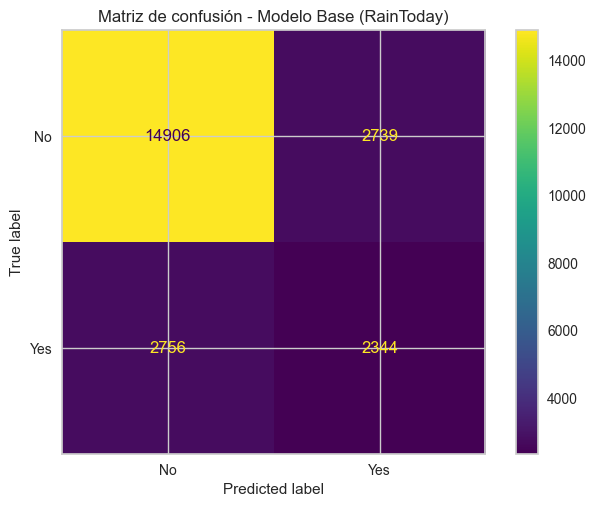

In [100]:
# graficamos la matriz de confusión para la regresión logística
cm_rain_today = confusion_matrix(y_validation, y_pred_base_raintoday)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_rain_today,display_labels=["No", "Yes"])

disp.plot()
plt.title("Matriz de confusión - Modelo Base (RainToday)")
plt.show()

In [101]:
# extraemos los valores de la matriz de confusión
vn, fp, fn, vp = cm_rain_today.ravel()

print("Verdaderos negativos:", vn)
print("Falsos positivos:", fp)
print("Falsos negativos:", fn)
print("Verdaderos positivos:", vp)

Verdaderos negativos: 14906
Falsos positivos: 2739
Falsos negativos: 2756
Verdaderos positivos: 2344


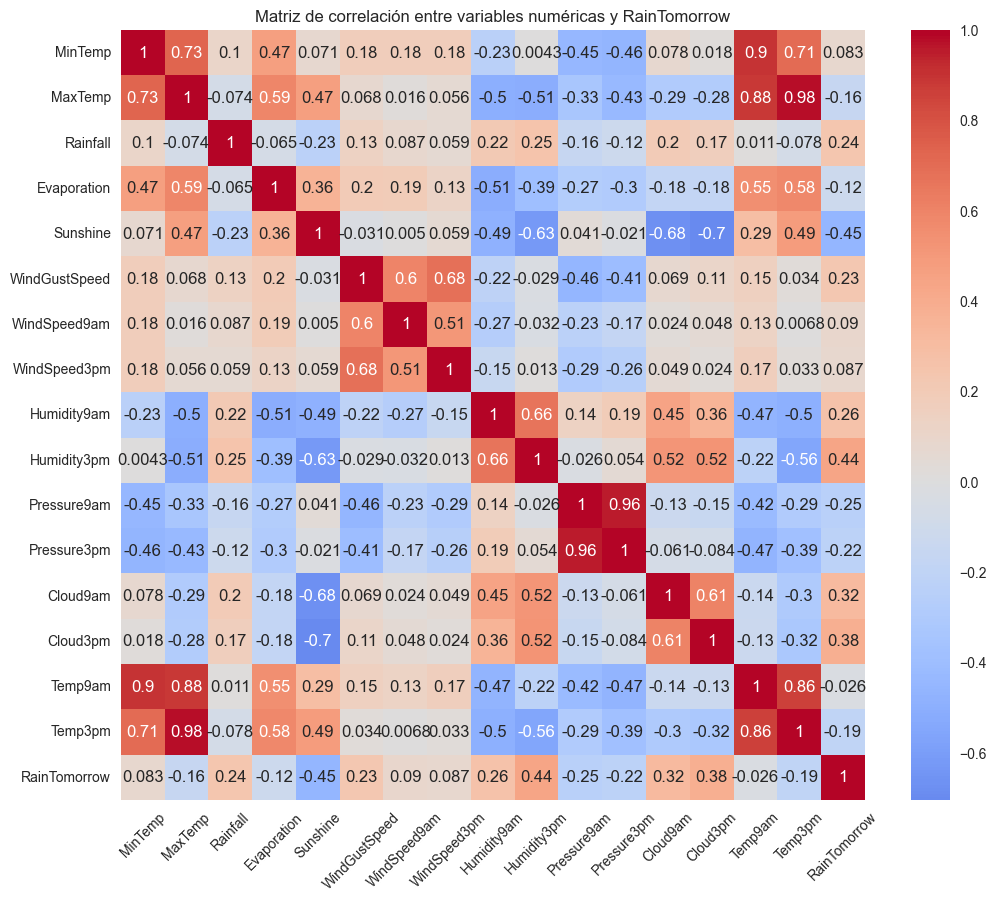

In [102]:
# copiamos las variables numéricas
df_corr = df_train[columnas_numericas].copy()

# agregamos el target codificado como variable binaria
df_corr["RainTomorrow"] = y_train

# calculamos la matriz de correlación incluyendo el target
correlacion2 = df_corr.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(correlacion2, cmap="coolwarm", center=0, annot=True)
plt.title("Matriz de correlación entre variables numéricas y RainTomorrow")
plt.xticks(rotation=45)
plt.show()

Para la regresión logística de una sola variable se utiliza `Sunshine`.

In [103]:
X_train_variable_unica = X_train[["Sunshine"]]
X_validation_unica = X_validation[["Sunshine"]]

# Incluso en este caso la mediana y el escalado se ajustan solo con train.
modelo_logistico_una_var = Pipeline(steps=[
    ("preprocesamiento", clone(preprocesamiento_numerico)),
    ("clasificador", LogisticRegression(
        max_iter=1000,
        random_state=RANDOM_STATE,
        class_weight="balanced",
    )),
])
modelo_logistico_una_var.fit(X_train_variable_unica, y_train)
y_pred_una_var = modelo_logistico_una_var.predict(X_validation_unica)
y_proba_logistico_una_var = modelo_logistico_una_var.predict_proba(X_validation_unica)[:, 1]


In [104]:
# calculamos métricas principales para evaluar el modelo de regresión logística
accuracy_logistico_una_var = accuracy_score(y_validation, y_pred_una_var)
precision_logistico_una_var = precision_score(y_validation, y_pred_una_var)
recall_logistico_una_var = recall_score(y_validation, y_pred_una_var)
f1_logistico_una_var = f1_score(y_validation, y_pred_una_var)
auc_logistico_una_var = roc_auc_score(y_validation, y_proba_logistico_una_var)

print("Accuracy:", accuracy_logistico_una_var)
print("Precision:", precision_logistico_una_var)
print("Recall:", recall_logistico_una_var)
print("F1-score:", f1_logistico_una_var)
print("ROC-AUC:", auc_logistico_una_var)

Accuracy: 0.7402066388217191
Precision: 0.4209188660801564
Recall: 0.42215686274509806
F1-score: 0.4215369554576603
ROC-AUC: 0.6986647997821968


In [105]:
f1_pred_base_una_var = f1_score(y_validation, y_pred_una_var, pos_label=1)
f1_comparacion_modelos["pred_base_una_var"] = f1_pred_base_una_var
accuracy_comparacion_modelos["pred_base_una_var"] = accuracy_score(y_validation, y_pred_una_var)
recall_comparacion_modelos["pred_base_una_var"] = recall_score(y_validation, y_pred_una_var, pos_label=1)

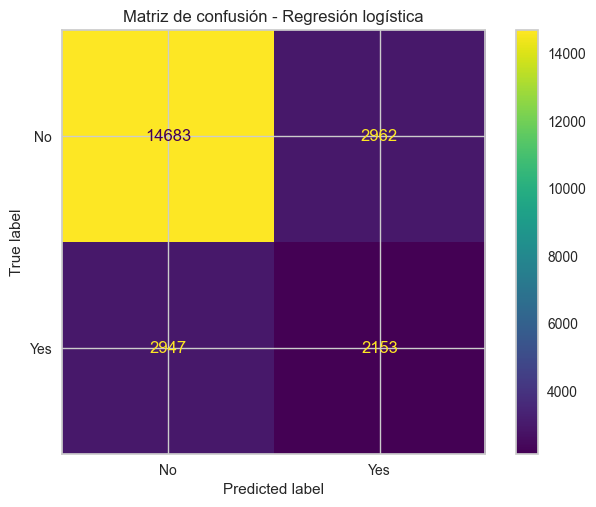

In [106]:
# graficamos la matriz de confusión para la regresión logística
cm_una_var = confusion_matrix(y_validation, y_pred_una_var)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_una_var,display_labels=["No", "Yes"])

disp.plot()
plt.title("Matriz de confusión - Regresión logística")
plt.show()

In [107]:
# extraemos los valores de la matriz de confusión
vn, fp, fn, vp = cm_una_var.ravel()

print("Verdaderos negativos:", vn)
print("Falsos positivos:", fp)
print("Falsos negativos:", fn)
print("Verdaderos positivos:", vp)

Verdaderos negativos: 14683
Falsos positivos: 2962
Falsos negativos: 2947
Verdaderos positivos: 2153


La regresión logística con todas las variables supera a los modelos base porque, además de mantener una accuracy mayor, logra identificar una parte de los días con lluvia. Esto se observa especialmente en el recall y el F1-score de la clase positiva.

Por lo tanto, la regresión logística aporta valor respecto de una estrategia ingenua basada solamente en predecir siempre la clase mayoritaria, basada en el valor de una variable o la regresión logística de una sola variable.

## Ítem 4: Optimización de hiperparámetros

En esta etapa exploratoria se ajustan:

- `C`, que controla la regularización. Se prueba un rango amplio para buscar un equilibrio entre ajuste y capacidad de generalización.
- `class_weight`, que permite modificar el peso de las clases durante el entrenamiento. Se incluye la opción `balanced` debido al desbalance de la variable objetivo.
  
  

In [108]:
# Grid search: el preprocesador completo está dentro del estimador evaluado.
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

grid_params = {
    "clasificador__C": [0.01, 0.1, 1, 10, 100, 1000, 10000],
    "clasificador__class_weight": [None, "balanced"],
}

modelo_grid = Pipeline(steps=[
    ("preprocesamiento", clone(preprocesamiento)),
    ("clasificador", LogisticRegression(
        max_iter=1000,
        solver="lbfgs",
        random_state=RANDOM_STATE,
    )),
])

grid_search = GridSearchCV(
    modelo_grid,
    grid_params,
    cv=cv,
    scoring="f1",
    n_jobs=-1,
)
grid_search.fit(X_train, y_train)
best_grid_model = grid_search.best_estimator_
grid_search_f1 = f1_score(y_validation, best_grid_model.predict(X_validation))
accuracy_grid = accuracy_score(y_validation, best_grid_model.predict(X_validation))
precision_grid = precision_score(y_validation, best_grid_model.predict(X_validation))
recall_grid = recall_score(y_validation, best_grid_model.predict(X_validation))


Se utiliza validación cruzada para obtener una estimación más estable del F1-score, promediando el desempeño sobre distintos folds. `StratifiedKFold` conserva aproximadamente la proporción de las clases en cada partición, algo especialmente importante en este dataset desbalanceado.

Se elige Grid Search porque el espacio definido contiene solo 14 combinaciones y puede recorrerse de manera exhaustiva. Esta búsqueda funciona como una primera comparación dentro de la familia de regresión logística; la selección final entre familias se realiza más adelante con probabilidades OOF sobre todo el conjunto de desarrollo.

In [109]:
print("Mejores parámetros:", grid_search.best_params_)
print("Mejor score:", grid_search.best_score_)
print("Accuracy:", accuracy_grid)
print("Precision:", precision_grid)
print("Recall:", recall_grid)
print("F1-score:", grid_search_f1)

Mejores parámetros: {'clasificador__C': 10, 'clasificador__class_weight': 'balanced'}
Mejor score: 0.6228755010774469
Accuracy: 0.787337876456364
Precision: 0.5171068036945492
Recall: 0.7794117647058824
F1-score: 0.621725189645734


En este benchmark, Grid Search selecciona `C=10` y `class_weight="balanced"`. El mejor F1 medio de CV es 0.6229 y el F1 sobre validation es 0.6217. Este resultado supera al dummy (F1 = 0), al baseline basado en `RainToday` (F1 = 0.4604) y a la regresión logística de una sola variable (F1 = 0.4215).

Frente a la regresión logística completa del Ítem 2 (F1 = 0.6218), el resultado de validation es prácticamente idéntico y levemente inferior. Por lo tanto, este experimento no aporta evidencia de una mejora relevante mediante el ajuste de hiperparámetros dentro de esta familia.

In [110]:
best_grid_model

Pipeline(steps=[('preprocesamiento',
                 Pipeline(steps=[('weather_features',
                                  WeatherFeatureTransformer(location_coordinates={'Adelaide': (-34.9281805,
                                                                                               138.5999312),
                                                                                  'Albany': (-35.0247822,
                                                                                             117.883608),
                                                                                  'Albury': (-36.0737734,
                                                                                             146.9135265),
                                                                                  'AliceSprings': (-23.6983884,
                                                                                                   133.8812885),
                                                                                  'BadgerysCreek': (-33.8831452,
                                                                                                    150.742466),
                                                                                  'Ballarat': (-37.5623013,
                                                                                               143.8605645),
                                                                                  'Bend...
                                                                   Pipeline(steps=(('fallback_imputer',
                                                                                    SimpleImputer(keep_empty_features=True,
                                                                                                  strategy='most_frequent')),
                                                                                   ('encoder',
                                                                                    OneHotEncoder(handle_unknown='ignore',
                                                                                                  sparse_output=False)))),
                                                                   ['WindGustDir',
                                                                    'WindDir9am',
                                                                    'WindDir3pm',
                                                                    'RainToday',
                                                                    'Season',
                                                                    'Region'])),
                                                    verbose_feature_names_out=False))])),
                ('clasificador',
                 LogisticRegression(C=10, class_weight='balanced',
                                    max_iter=1000, random_state=42))])

In [111]:
preprocesamiento_grid = best_grid_model.named_steps["preprocesamiento"]
clasificador = best_grid_model.named_steps["clasificador"]


Se separan el preprocesador y el clasificador del pipeline para analizar el modelo con SHAP.

In [112]:
# Este preprocesador fue reajustado por GridSearchCV sobre todo X_train después
# de elegir hiperparámetros; validación externa recibe únicamente transform.
X_train_scaled = preprocesamiento_grid.transform(X_train)
X_validation_scaled = preprocesamiento_grid.transform(X_validation)


Los datos se transforman con el mismo preprocesador del pipeline para que SHAP reciba la matriz utilizada por el clasificador.

In [113]:
feature_names = list(preprocesamiento_grid.get_feature_names_out())


Obtenemos el nombre de todas las columnas, numéricas + categóricas expandidas por OneHotEncoder

## Ítem 5: Explicabilidad de modelos mediante SHAP

In [114]:
# Crea un objeto explainer SHAP
explainer = shap.LinearExplainer(clasificador, X_train_scaled, feature_names=feature_names)

# Calcula los valores SHAP para un conjunto de ejemplos de validación
shap_values = explainer.shap_values(X_validation_scaled)

In [115]:
print(explainer.expected_value)

-0.5606609112915626


El valor base del modelo indica que, antes de considerar las variables de esta observación, es más probable que no llueva al día siguiente.

In [116]:
shap_values.shape

(22745, 80)

In [117]:
shap_values[0]

array([-2.40268800e-02,  9.20425721e-03,  4.29096903e-02,  3.46028327e-03,
        4.64164768e-03, -2.20645354e-01,  5.64764032e-02,  1.55502055e-01,
        1.31623515e-01,  2.74126538e-01, -5.47500376e-01,  9.40722591e-01,
       -7.00543977e-03, -7.98777844e-02, -7.70316583e-02, -1.76510603e-02,
        1.43522951e-03,  4.37467346e-03, -4.06253262e-03, -2.13642347e-03,
        3.39769926e-03,  7.45941984e-03, -1.09797783e-03,  5.85065397e-02,
       -4.37986864e-03, -5.06865161e-03, -1.92729432e-03,  5.57604368e-03,
        1.45549237e-02,  9.02313901e-04, -1.26157892e-05,  2.23747514e-03,
        6.20134151e-03, -2.71384943e-03,  8.01870851e-03, -4.41707995e-04,
       -5.77615418e-03,  2.03107105e-01,  3.74407331e-03, -1.30533569e-03,
        2.15515653e-02,  1.08367115e-02,  4.52412167e-03,  2.98747525e-03,
       -2.32516349e-03, -3.27893213e-03, -1.42894830e-03, -2.16246079e-03,
        6.38351058e-03,  4.40768458e-03,  1.09474889e-02, -1.36374303e-02,
        1.03178763e-02, -

### Gráficas a nivel local

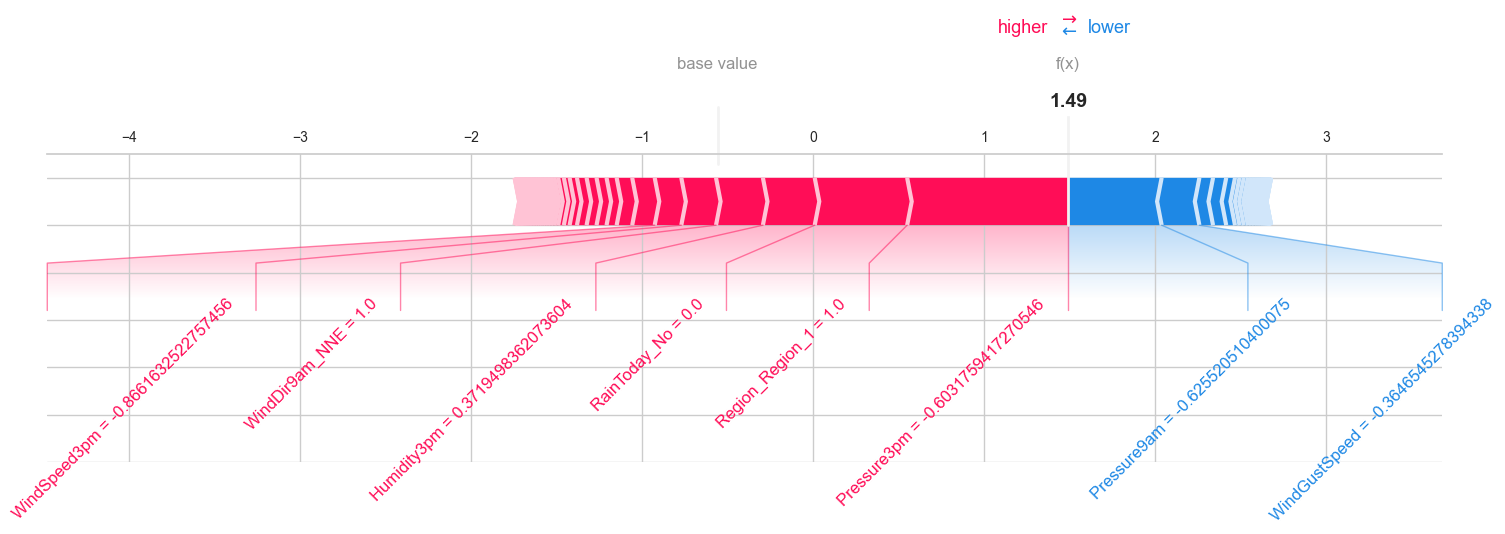

In [118]:
index=0
shap.force_plot(explainer.expected_value, shap_values[index], X_validation_scaled[index],
feature_names=feature_names, matplotlib=True, figsize=(18, 4),
text_rotation=45)

Para la primera observación del conjunto de validación, los aportes desplazan la salida desde un valor base negativo hasta un logit positivo cercano a 1.49.

En conjunto, las variables que empujan hacia la clase positiva predominan sobre las que reducen la salida del modelo.

Al transformar ese logit con la función sigmoide, la probabilidad estimada de lluvia para esta observación es aproximadamente 81.6%.

In [119]:
explanation = shap.Explanation(values=shap_values[index], base_values=explainer.expected_value, feature_names=feature_names)

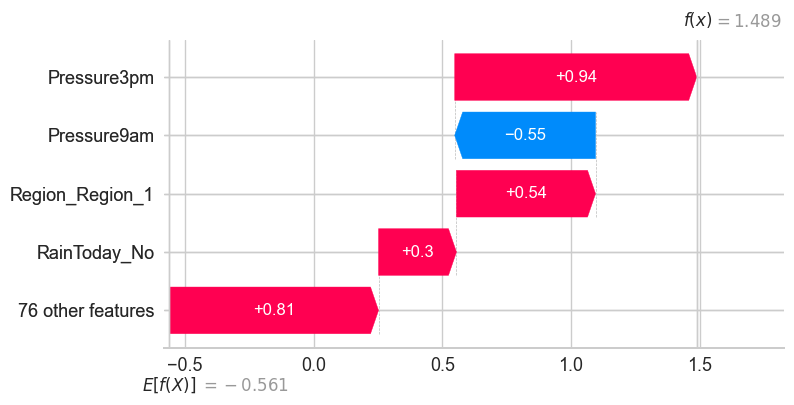

In [120]:
shap.plots.waterfall(explanation, max_display=5)

El gráfico waterfall parte de un valor base cercano a -0.56. Para esta observación:
* `Pressure3pm`, la pertenencia a `Region_1`, `RainToday_No` y `Humidity3pm` aportan hacia una mayor salida del modelo.
* `Pressure9am` y `WindGustSpeed` aportan en sentido contrario.

* El efecto agregado del resto de las variables también es positivo.

El resultado final es un logit cercano a 1.49, consistente con una probabilidad alta para la clase lluvia.

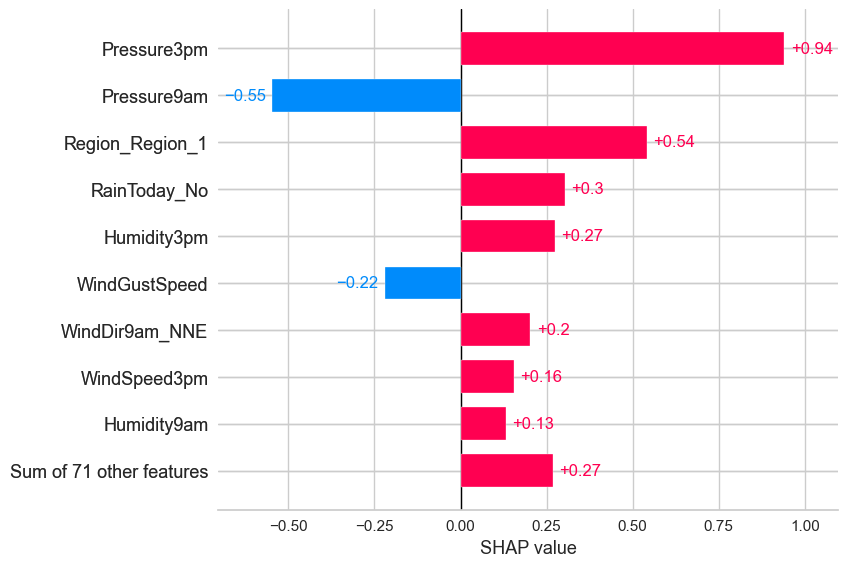

In [121]:
shap.plots.bar(explanation)

* Los mayores aportes positivos individuales provienen de `Pressure3pm`, `Region_1`, `RainToday_No` y `Humidity3pm`.

* Los principales aportes negativos corresponden a `Pressure9am` y `WindGustSpeed`.

El resto de las variables tiene contribuciones individuales menores, aunque su efecto agregado también influye en la predicción.


### Gráficas a nivel global

In [122]:
explanation = shap.Explanation(values=shap_values, base_values=explainer.expected_value, feature_names=feature_names, data=X_validation_scaled)

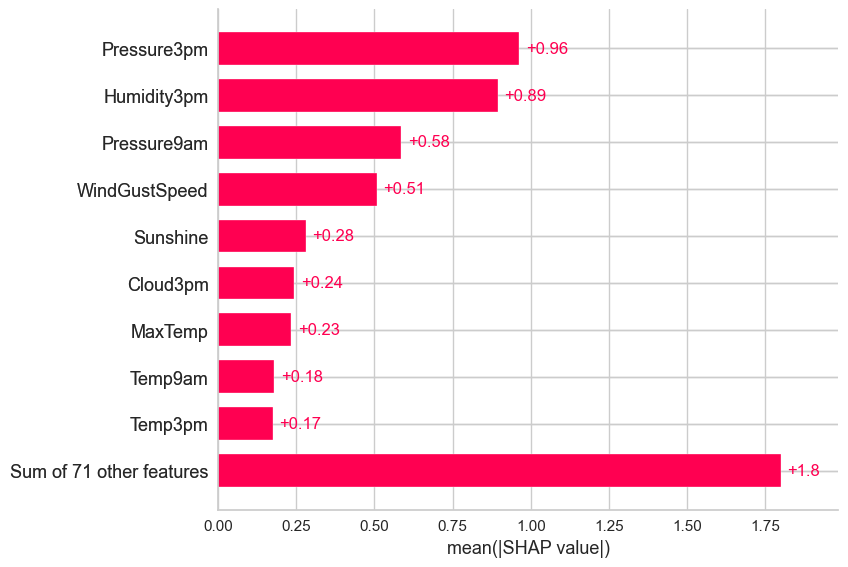

In [123]:
shap.plots.bar(explanation)

El gráfico de barras global muestra la magnitud promedio del aporte de cada variable en el conjunto de validación, aunque no indica si su efecto empuja la predicción hacia "lloverá" o hacia "no lloverá".

Las variables individuales con mayor importancia media son `Pressure3pm`, `Humidity3pm`, `Pressure9am`, `WindGustSpeed`, `Sunshine`, `Cloud3pm`, `MaxTemp`, `Temp9am` y `Temp3pm`. El resto presenta menor importancia individual, aunque su contribución agregada no es despreciable.

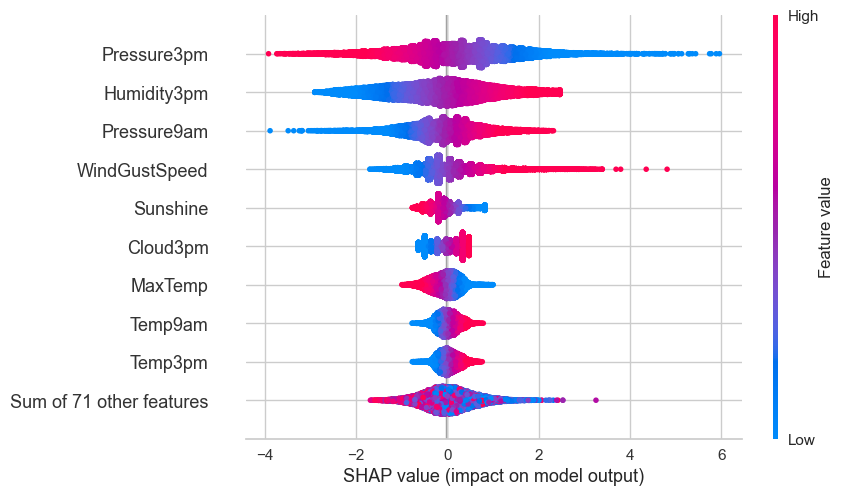

In [124]:
shap.plots.beeswarm(explanation)

El beeswarm permite analizar la dirección de las variables más importantes:

* En `Pressure3pm`, los valores bajos se asocian con una salida mayor y los altos con una salida menor.

* En `Humidity3pm`, los valores altos tienden a aumentar la predicción de lluvia y los bajos a reducirla.

* Para `Pressure9am`, el patrón del modelo es inverso al de `Pressure3pm`: los valores altos tienden a aportar positivamente y los bajos negativamente, en presencia de las demás variables.

* Las ráfagas más fuertes en `WindGustSpeed` tienden a elevar la salida del modelo.

* Más horas de `Sunshine` y valores altos de `MaxTemp` tienden a reducir la predicción de lluvia.

## Ítem 6: AutoML con PyCaret

In [125]:
# PyCaret recibe datos sin imputar, codificar, normalizar ni balancear.
# Date -> Season es determinístico; todo lo que aprende parámetros queda en
# el pipeline interno de PyCaret y se reajusta dentro de cada fold.
df_pycaret_train = prepare_pycaret_frame(X_train)
df_pycaret_train["RainTomorrow"] = y_train

df_pycaret_validation = prepare_pycaret_frame(X_validation)
df_pycaret_validation["RainTomorrow"] = y_validation

df_pycaret_train.head()


,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,WindDir3pm,...,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,Season,RainTomorrow
57764,Ballarat,4.6,7.5,0.2,NaN,NaN,W,63.0,N,WNW,...,100.0,1010.3,1006.8,8.0,7.0,5.2,5.9,No,Winter,1
31606,Sydney,18.9,25.2,0.2,2.8,8.0,ENE,45.0,E,E,...,61.7,1013.9,1012.6,NaN,NaN,22.9,24.7,No,Summer,1
42226,Williamtown,3.6,18.1,0.0,NaN,NaN,WNW,37.0,WNW,N,...,29.4,1021.3,1017.7,NaN,NaN,12.8,17.1,No,Winter,0
38451,WaggaWagga,8.7,15.1,9.8,0.6,6.2,NW,30.0,WNW,NW,...,65.8,1014.7,1014.2,8.0,4.0,9.0,14.1,Yes,Winter,1
33683,SydneyAirport,10.2,20.1,0.4,1.6,9.5,NW,22.0,NW,SSE,...,57.5,1019.9,1016.4,1.0,1.0,13.7,19.1,No,Winter,0


PyCaret se utiliza como benchmark para comparar varias familias de modelos. Sus imputadores, codificadores, normalización y balanceo forman parte del pipeline que `compare_models` clona y ajusta dentro de cada fold; el conjunto de validación se utiliza posteriormente para caracterizar el desempeño del candidato elegido en este experimento.


In [126]:
# Configuración fold-local de PyCaret. No recibe datos preajustados.
experimento_pycaret = setup(
    data=df_pycaret_train,
    target="RainTomorrow",
    session_id=RANDOM_STATE,
    train_size=0.8,
    normalize=True,
    fix_imbalance=True,
    fold_strategy=StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=RANDOM_STATE,
    ),
    fold=5,
    verbose=False,
)


Se comparan varios modelos automáticamente utilizando F1-score como métrica principal. Para mantener un costo computacional razonable, el benchmark se limita a regresión logística, árbol de decisión, Random Forest, AdaBoost y Gradient Boosting.

In [127]:
mejor_modelo_pycaret = compare_models(
    sort="F1",
    include=["lr", "dt", "rf", "ada", "gbc"]
)

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
rf,Random Forest Classifier,0.8521,0.8817,0.5759,0.7099,0.6359,0.5444,0.5491,4.8380
gbc,Gradient Boosting Classifier,0.8393,0.8664,0.6046,0.6530,0.6278,0.5256,0.5262,10.1180
lr,Logistic Regression,0.7881,0.8659,0.7690,0.5185,0.6194,0.4801,0.4981,1.4720
ada,Ada Boost Classifier,0.8162,0.8455,0.6134,0.5861,0.5994,0.4802,0.4805,3.7160
dt,Decision Tree Classifier,0.7771,0.6975,0.5533,0.5026,0.5267,0.3814,0.3822,1.7740


In [128]:
mejor_modelo_pycaret

RandomForestClassifier(bootstrap=True, ccp_alpha=0.0, class_weight=None,
                       criterion='gini', max_depth=None, max_features='sqrt',
                       max_leaf_nodes=None, max_samples=None,
                       min_impurity_decrease=0.0, min_samples_leaf=1,
                       min_samples_split=2, min_weight_fraction_leaf=0.0,
                       monotonic_cst=None, n_estimators=100, n_jobs=-1,
                       oob_score=False, random_state=42, verbose=0,
                       warm_start=False)

Esta comparación con PyCaret funciona como un benchmark exploratorio entre familias de modelos. Random Forest obtuvo el mayor F1-score medio (0.6359) y un AUC medio de 0.8817. La regresión logística alcanzó el mayor recall (0.7690), a costa de una precision menor. Estas observaciones permiten orientar la experimentación, mientras que la selección final se realiza posteriormente mediante CV estratificada de 5 folds y probabilidades OOF sobre todo el conjunto de desarrollo.

Decision Tree presentó el peor rendimiento general del benchmark, con menor F1-score y menor AUC, lo que indica que un árbol individual generaliza peor que los ensambles evaluados, como Random Forest o Gradient Boosting.

In [129]:
# Candidato con mayor F1 dentro del benchmark exploratorio de PyCaret.
modelo_pycaret_benchmark = mejor_modelo_pycaret

In [130]:
# Evaluamos el candidato del benchmark sobre el conjunto de validación.
predicciones_pycaret = predict_model(modelo_pycaret_benchmark, data=df_pycaret_validation)

predicciones_pycaret.head()

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Random Forest Classifier,0.8500,0.8793,0.5686,0.7054,0.6297,0.5370,0.5419


,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,WindDir3pm,...,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,Season,RainTomorrow,prediction_label,prediction_score
122329,Perth,10.9,21.900000,6.0,2.4,7.2,NW,35.0,NNE,WNW,...,1011.299988,7.0,4.0,14.4,20.200001,Yes,Winter,1,1,0.64
15278,Newcastle,7.6,17.799999,0.0,NaN,NaN,NaN,NaN,W,NW,...,NaN,1.0,2.0,12.6,17.799999,No,Winter,0,0,0.95
76430,Portland,12.6,19.200001,0.2,4.6,2.1,WNW,56.0,NNW,WNW,...,1009.700012,8.0,6.0,17.6,19.799999,No,Autumn,1,1,0.83
26289,Penrith,15.4,25.700001,0.0,NaN,NaN,S,22.0,S,SSE,...,NaN,NaN,NaN,22.6,23.100000,No,Summer,0,0,0.81
43208,Wollongong,15.3,21.100000,2.2,NaN,NaN,NNW,30.0,SSE,N,...,1019.299988,7.0,7.0,17.9,20.200001,Yes,Spring,0,1,0.74


In [131]:
predicciones_pycaret.columns

Index(['Location', 'MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation', 'Sunshine',
       'WindGustDir', 'WindGustSpeed', 'WindDir9am', 'WindDir3pm',
       'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm',
       'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm', 'Temp9am',
       'Temp3pm', 'RainToday', 'Season', 'RainTomorrow', 'prediction_label',
       'prediction_score'],
      dtype='object')

In [132]:
# Valores reales y predichos
y_true_pycaret = predicciones_pycaret["RainTomorrow"]
y_pred_pycaret = predicciones_pycaret["prediction_label"]

# Métricas
accuracy_pycaret = accuracy_score(y_true_pycaret, y_pred_pycaret)
precision_pycaret = precision_score(y_true_pycaret, y_pred_pycaret)
recall_pycaret = recall_score(y_true_pycaret, y_pred_pycaret)
f1_pycaret = f1_score(y_true_pycaret, y_pred_pycaret)

print("Accuracy:", accuracy_pycaret)
print("Precision:", precision_pycaret)
print("Recall:", recall_pycaret)
print("F1-score:", f1_pycaret)

Accuracy: 0.8500329742800615
Precision: 0.7054244709316468
Recall: 0.5686274509803921
F1-score: 0.6296819020736076


In [133]:
f1_comparacion_modelos["PyCaret"] = f1_pycaret
accuracy_comparacion_modelos["PyCaret"] = accuracy_pycaret
recall_comparacion_modelos["PyCaret"] = recall_score(y_validation, y_pred_pycaret, pos_label=1)

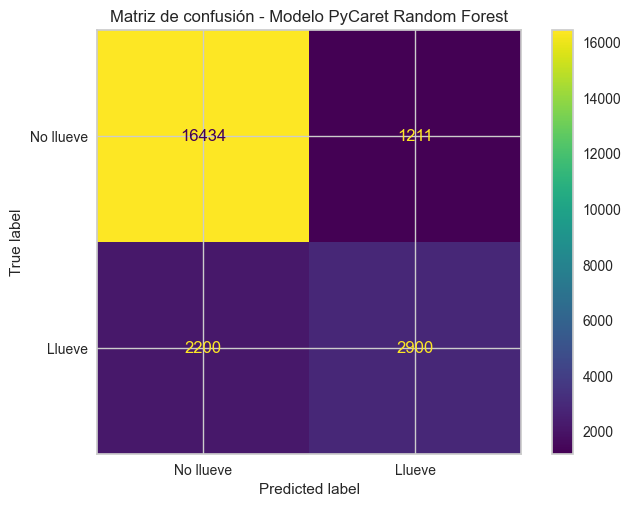

In [134]:
cm_pycaret = confusion_matrix(y_true_pycaret, y_pred_pycaret)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_pycaret,
    display_labels=["No llueve", "Llueve"]
)

disp.plot()
plt.title("Matriz de confusión - Modelo PyCaret Random Forest")
plt.show()

Al evaluar el candidato Random Forest del benchmark PyCaret sobre el conjunto de validación, se obtuvieron los siguientes resultados exploratorios:

- Accuracy: 0.8500
- Precision: 0.7054
- Recall: 0.5686
- F1-score: 0.6297

La matriz de confusión muestra 16434 verdaderos negativos y 2900 verdaderos positivos, junto con 1211 falsos positivos y 2200 falsos negativos. En este benchmark externo, Random Forest obtiene un F1-score levemente mayor que la regresión logística completa, con mayor precision y menor recall. No se reporta ROC-AUC externo porque esta celda no reconstruye explícitamente la probabilidad de la clase positiva a partir de la salida de PyCaret.

Dado el desbalance del dataset, la accuracy no se utiliza como única medida. Se prioriza el F1-score porque combina precision y recall sobre la clase positiva, correspondiente a los días en los que llueve.

In [135]:
# Finalizamos el candidato exploratorio de PyCaret dentro del conjunto de entrenamiento.
# Todavia no se guarda ni se evalua sobre el test final.
pipeline_pycaret_seleccionado = finalize_model(mejor_modelo_pycaret)
pipeline_pycaret_seleccionado

Pipeline(memory=Memory(location=None),
         steps=[('numerical_imputer',
                 TransformerWrapper(exclude=None,
                                    include=['MinTemp', 'MaxTemp', 'Rainfall',
                                             'Evaporation', 'Sunshine',
                                             'WindGustSpeed', 'WindSpeed9am',
                                             'WindSpeed3pm', 'Humidity9am',
                                             'Humidity3pm', 'Pressure9am',
                                             'Pressure3pm', 'Cloud9am',
                                             'Cloud3pm', 'Temp9am', 'Temp3pm'],
                                    transformer=SimpleImputer(add_indicator=Fa...
                 RandomForestClassifier(bootstrap=True, ccp_alpha=0.0,
                                        class_weight=None, criterion='gini',
                                        max_depth=None, max_features='sqrt',
                                        max_leaf_nodes=None, max_samples=None,
                                        min_impurity_decrease=0.0,
                                        min_samples_leaf=1, min_samples_split=2,
                                        min_weight_fraction_leaf=0.0,
                                        monotonic_cst=None, n_estimators=100,
                                        n_jobs=-1, oob_score=False,
                                        random_state=42, verbose=0,
                                        warm_start=False))],
         verbose=False)

## Ítem 7: Implementación de una red neuronal

La red neuronal se implementa como un modelo secuencial para clasificación binaria. La salida utiliza una neurona con activación sigmoide, ya que se busca predecir la probabilidad de pertenecer a la clase positiva (RainTomorrow = Yes).

Se utiliza binary_crossentropy como función de pérdida porque el problema es binario, y un optimizador como Adam para actualizar los pesos durante el entrenamiento.

In [136]:
# Primero se divide el entrenamiento crudo de la red.
X_train_nn_raw, X_valid_nn_raw, y_train_nn, y_valid_nn = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y_train,
)

# Solo el subtrain interno ejecuta fit; ambas validaciones reciben transform.
preprocesamiento_nn = build_weather_preprocessor(
    location_coordinates=location_coordinates,
    random_state=RANDOM_STATE,
)
X_train_nn = preprocesamiento_nn.fit_transform(X_train_nn_raw)
X_valid_nn = preprocesamiento_nn.transform(X_valid_nn_raw)
X_validation_nn = preprocesamiento_nn.transform(X_validation)

fit_indices_nn = set(
    preprocesamiento_nn.named_steps["weather_features"].fit_indices_
)
assert fit_indices_nn == set(X_train_nn_raw.index)
assert fit_indices_nn.isdisjoint(X_valid_nn_raw.index)
assert fit_indices_nn.isdisjoint(X_validation.index)
feature_names_nn = list(preprocesamiento_nn.get_feature_names_out())


In [137]:
class NeuralNetwork:
    def __init__(self, epochs=50, batch_size=16, learning_rate=0.01, dropout_rate=0.0):
        # inicializamos parámetros de entrenamiento
        self.epochs = epochs
        self.batch_size = batch_size
        self.learning_rate = learning_rate
        self.dropout_rate = dropout_rate
        self.model = None

    def build_model(self, input_shape):
        # capas ocultas con relu, dropout para regularización, y salida sigmoid para clasificación binaria
        model = tf.keras.models.Sequential([
            tf.keras.layers.Dense(30, activation='relu', input_shape=(input_shape,)),
            tf.keras.layers.Dropout(self.dropout_rate),
            tf.keras.layers.Dense(26, activation='relu'),
            tf.keras.layers.Dropout(self.dropout_rate),
            tf.keras.layers.Dense(24, activation='relu'),
            tf.keras.layers.Dense(1, activation='sigmoid')
        ])
        # utilizamos binary_crossentropy como función de pérdida para clasificación binaria
        optimizer = tf.keras.optimizers.Adam(learning_rate=self.learning_rate)
        model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])
        self.model = model

    def train(self, X_train, y_train, X_valid, y_valid):
        # Fit del modelo. Devuelve la evolución de la función de pérdida
        history = self.model.fit(X_train, y_train, validation_data=(X_valid, y_valid),
                                 epochs=self.epochs, batch_size=self.batch_size, verbose=0)
        return history.history['loss'], history.history['val_loss']

    def predict_probabilidad(self, X):
        # probabilidad de la clase positiva (lluvia)
        return self.model.predict(X, verbose=0).flatten()

    def predict(self, X, threshold=0.5):
        # umbral, aplica etiquetas 0 o 1 según la probabilidad
        return (self.predict_probabilidad(X) >= threshold).astype(int)

In [138]:
# construimos el modelo
nn = NeuralNetwork(epochs=200, batch_size=64, learning_rate=0.001, dropout_rate=0.3)
nn.build_model(input_shape=X_train_nn.shape[1])

# mostramos la arquitectura de la red antes de entrenarla
nn.model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 30)             │         2,430 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 26)             │           806 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 26)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 24)             │           648 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            25 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,909 (15.27 KB)

 Trainable params: 3,909 (15.27 KB)

 Non-trainable params: 0 (0.00 B)

In [139]:
# lo entrenamos
history_loss, history_val_loss = nn.train(X_train_nn, y_train_nn, X_valid_nn, y_valid_nn)

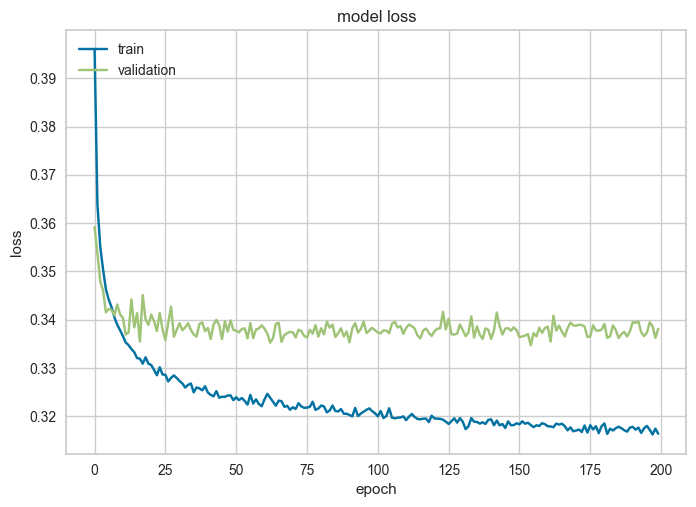

In [140]:
plt.plot(history_loss, label='train')
plt.plot(history_val_loss, label='validation')
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'validation'], loc='upper left')
plt.show()

La pérdida de entrenamiento continúa disminuyendo durante las épocas, mientras que la pérdida de validación se estabiliza antes y mantiene pequeñas oscilaciones. La separación gradual entre ambas curvas sugiere un sobreajuste leve, sin una divergencia abrupta.

In [141]:
y_pred_nn = nn.predict(X_validation_nn)
y_probabilidad_nn = nn.predict_probabilidad(X_validation_nn)
# guardamos las métricas principales para poder compararlas luego con otros modelos
accuracy_nn = accuracy_score(y_validation, y_pred_nn)
precision_nn = precision_score(y_validation, y_pred_nn)
recall_nn = recall_score(y_validation, y_pred_nn)
f1_nn = f1_score(y_validation, y_pred_nn)
auc_nn = roc_auc_score(y_validation, y_probabilidad_nn)

print(classification_report(y_validation, y_pred_nn))


              precision    recall  f1-score   support

           0       0.88      0.94      0.91     17645
           1       0.74      0.56      0.63      5100

    accuracy                           0.86     22745
   macro avg       0.81      0.75      0.77     22745
weighted avg       0.85      0.86      0.85     22745



En esta ejecución, la red neuronal base obtiene accuracy 0.86, precision 0.74, recall 0.56 y F1-score 0.63 para la clase positiva. Su F1 es levemente mayor que el de la regresión logística completa y el de Grid Search, ambos cercanos a 0.62, y su ROC-AUC también es mayor: 0.882 frente a 0.867 de la regresión logística completa.

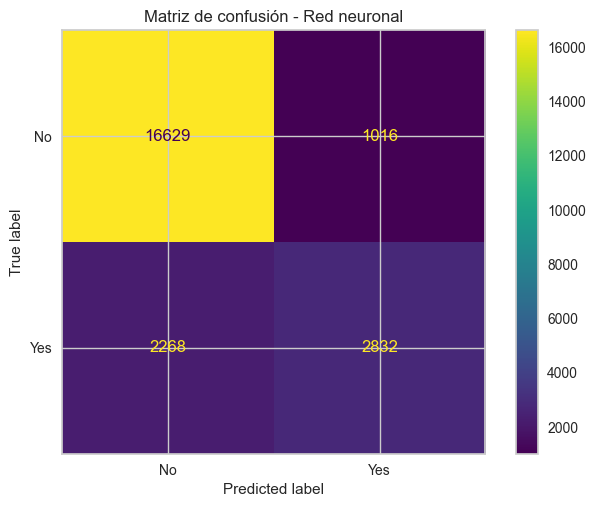

In [142]:
cm_nn = confusion_matrix(y_validation, y_pred_nn)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_nn,
    display_labels=["No", "Yes"]
)

disp.plot()
plt.title("Matriz de confusión - Red neuronal")
plt.show()

La matriz de confusión muestra que la red neuronal clasifica correctamente una gran cantidad de días sin lluvia, que es la clase mayoritaria del dataset.

Para la clase "Yes", el modelo logra detectar varios días lluviosos, pero también mantiene una cantidad importante de falsos negativos. Estos falsos negativos representan días en los que realmente llovió, pero el modelo predijo que no iba a llover.

Este resultado confirma lo observado en las métricas, la red neuronal tiene buen rendimiento general, pero la detección de la clase positiva sigue siendo el punto más difícil por el desbalance del dataset.

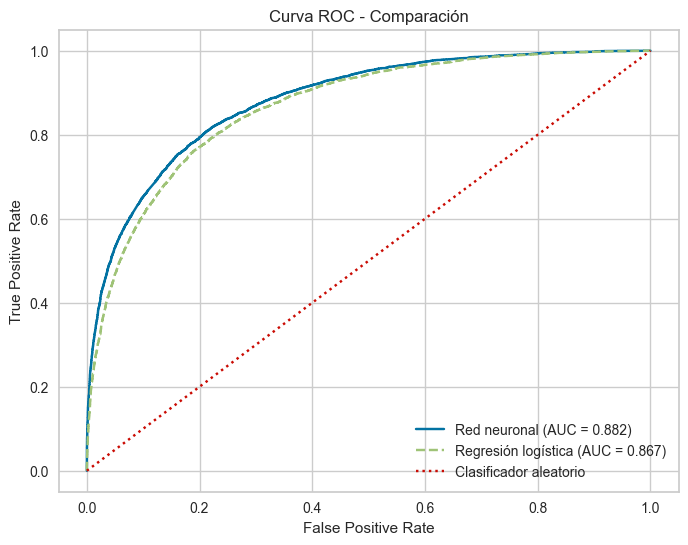

In [143]:
fpr_nn, tpr_nn, thresholds_nn = roc_curve(y_validation, y_probabilidad_nn)


plt.figure(figsize=(8, 6))
plt.plot(fpr_nn, tpr_nn, label=f"Red neuronal (AUC = {auc_nn:.3f})")
plt.plot(fpr_logistico, tpr_logistico, label=f"Regresión logística (AUC = {auc_logistico:.3f})", linestyle='--')
plt.plot([0, 1], [0, 1], linestyle=":", label="Clasificador aleatorio")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC - Comparación")
plt.legend()
plt.show()

La red neuronal obtiene un AUC más alto que la regresión logística evaluada previamente. Este valor indica una buena capacidad para distinguir entre las clases "llueve" y "no llueve".

### Optimización de hiperparámetros de la red neuronal

Como parte de la experimentación con redes neuronales, se realiza una búsqueda acotada de hiperparámetros. No se utiliza una grilla extensa porque el entrenamiento de estas configuraciones tiene un costo computacional mayor.

Se prueban distintas combinaciones de `epochs`, `batch_size`, `learning_rate` y `dropout_rate`. Esta primera comparación utiliza el F1-score sobre el conjunto de validación como referencia exploratoria. Más adelante, las configuraciones de red se incorporan a la selección final mediante predicciones OOF sobre todo el conjunto de desarrollo.

In [144]:
# definimos algunas configuraciones de hiperparámetros para probar
configuraciones_nn = [
    {"epochs": 50, "batch_size": 64, "learning_rate": 0.001, "dropout_rate": 0.2},
    {"epochs": 50, "batch_size": 64, "learning_rate": 0.001, "dropout_rate": 0.3},
    {"epochs": 50, "batch_size": 128, "learning_rate": 0.001, "dropout_rate": 0.3},
    {"epochs": 50, "batch_size": 64, "learning_rate": 0.0005, "dropout_rate": 0.3},
    {"epochs": 50, "batch_size": 128, "learning_rate": 0.0005, "dropout_rate": 0.4},
]

resultados_nn = []

for i, config in enumerate(configuraciones_nn, start=1):
    print(f"Entrenando configuración {i}: {config}")

    # fijamos semilla para que los resultados sean más reproducibles
    tf.keras.utils.set_random_seed(42)

    # construimos la red con la configuración actual
    modelo_nn = NeuralNetwork(
        epochs=config["epochs"],
        batch_size=config["batch_size"],
        learning_rate=config["learning_rate"],
        dropout_rate=config["dropout_rate"]
    )

    modelo_nn.build_model(input_shape=X_train_nn.shape[1])

    # entrenamos usando train y validación
    history_loss, history_val_loss = modelo_nn.train(
        X_train_nn,
        y_train_nn,
        X_valid_nn,
        y_valid_nn
    )

    # evaluamos cada configuración sobre el conjunto de validación
    y_pred_valid = modelo_nn.predict(X_valid_nn)
    y_proba_valid = modelo_nn.predict_probabilidad(X_valid_nn)

    accuracy_valid = accuracy_score(y_valid_nn, y_pred_valid)
    precision_valid = precision_score(y_valid_nn, y_pred_valid)
    recall_valid = recall_score(y_valid_nn, y_pred_valid)
    f1_valid = f1_score(y_valid_nn, y_pred_valid)
    auc_valid = roc_auc_score(y_valid_nn, y_proba_valid)

    resultados_nn.append({
        "modelo": f"NN config {i}",
        "epochs": config["epochs"],
        "batch_size": config["batch_size"],
        "learning_rate": config["learning_rate"],
        "dropout_rate": config["dropout_rate"],
        "accuracy_valid": accuracy_valid,
        "precision_valid": precision_valid,
        "recall_valid": recall_valid,
        "f1_valid": f1_valid,
        "auc_valid": auc_valid,
        "modelo_entrenado": modelo_nn
    })

resultados_hiperparametros_nn = pd.DataFrame(resultados_nn)

# mostramos los resultados ordenados por F1-score
resultados_hiperparametros_nn.sort_values(by="f1_valid", ascending=False)

Entrenando configuración 1: {'epochs': 50, 'batch_size': 64, 'learning_rate': 0.001, 'dropout_rate': 0.2}


Entrenando configuración 2: {'epochs': 50, 'batch_size': 64, 'learning_rate': 0.001, 'dropout_rate': 0.3}


Entrenando configuración 3: {'epochs': 50, 'batch_size': 128, 'learning_rate': 0.001, 'dropout_rate': 0.3}


Entrenando configuración 4: {'epochs': 50, 'batch_size': 64, 'learning_rate': 0.0005, 'dropout_rate': 0.3}


Entrenando configuración 5: {'epochs': 50, 'batch_size': 128, 'learning_rate': 0.0005, 'dropout_rate': 0.4}


,modelo,epochs,batch_size,learning_rate,dropout_rate,accuracy_valid,precision_valid,recall_valid,f1_valid,auc_valid,modelo_entrenado
4,NN config 5,50,128,0.0005,0.4,0.858870,0.753351,0.550980,0.636467,0.883585,<__main__.NeuralNetwork object at 0x0000024300...
2,NN config 3,50,128,0.0010,0.3,0.857386,0.759162,0.533088,0.626350,0.884336,<__main__.NeuralNetwork object at 0x0000024284...
3,NN config 4,50,64,0.0005,0.3,0.858046,0.768568,0.525000,0.623853,0.884613,<__main__.NeuralNetwork object at 0x0000024304...
0,NN config 1,50,64,0.0010,0.2,0.858430,0.773256,0.521569,0.622951,0.883043,<__main__.NeuralNetwork object at 0x0000024284...
1,NN config 2,50,64,0.0010,0.3,0.857606,0.774419,0.514951,0.618578,0.883878,<__main__.NeuralNetwork object at 0x0000024283...


En esta comparación exploratoria, las configuraciones se ordenan según el F1-score del conjunto de validación, la métrica principal elegida para la clase positiva.

La configuración con mejor F1-score en esta partición fue "NN config 5", con 50 épocas, batch size de 128, learning rate de 0.0005 y dropout de 0.4. Este resultado describe el benchmark sobre validation; la elección definitiva de arquitectura e hiperparámetros se determina después mediante la evaluación OOF de todas las configuraciones candidatas.

In [145]:
# seleccionamos la configuración con mejor F1-score en validación
indice_mejor_nn = resultados_hiperparametros_nn["f1_valid"].idxmax()

mejor_resultado_nn = resultados_hiperparametros_nn.loc[indice_mejor_nn]

nn_optimizada = mejor_resultado_nn["modelo_entrenado"]

mejor_resultado_nn.drop(labels=["modelo_entrenado"])

modelo             NN config 5
epochs                      50
batch_size                 128
learning_rate           0.0005
dropout_rate               0.4
accuracy_valid         0.85887
precision_valid       0.753351
recall_valid           0.55098
f1_valid              0.636467
auc_valid             0.883585
Name: 4, dtype: object

In [146]:
# La validación externa solo atraviesa transform del preprocesador NN ya ajustado.
y_pred_nn_opt = nn_optimizada.predict(X_validation_nn)
y_probabilidad_nn_opt = nn_optimizada.predict_probabilidad(X_validation_nn)

accuracy_nn_opt = accuracy_score(y_validation, y_pred_nn_opt)
precision_nn_opt = precision_score(y_validation, y_pred_nn_opt)
recall_nn_opt = recall_score(y_validation, y_pred_nn_opt)
f1_nn_opt = f1_score(y_validation, y_pred_nn_opt)
auc_nn_opt = roc_auc_score(y_validation, y_probabilidad_nn_opt)

print("Accuracy:", accuracy_nn_opt)
print("Precision:", precision_nn_opt)
print("Recall:", recall_nn_opt)
print("F1-score:", f1_nn_opt)
print("ROC-AUC:", auc_nn_opt)
print("\nReporte de clasificación:")
print(classification_report(y_validation, y_pred_nn_opt))


Accuracy: 0.8552648933831611
Precision: 0.7404255319148936
Recall: 0.5458823529411765
F1-score: 0.6284424379232506
ROC-AUC: 0.8830513448791248

Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.88      0.94      0.91     17645
           1       0.74      0.55      0.63      5100

    accuracy                           0.86     22745
   macro avg       0.81      0.75      0.77     22745
weighted avg       0.85      0.86      0.85     22745



In [147]:
f1_comparacion_modelos["red_neuronal"] = f1_nn_opt
accuracy_comparacion_modelos["red_neuronal"] = accuracy_nn_opt
recall_comparacion_modelos["red_neuronal"] = recall_score(y_validation, y_pred_nn_opt, pos_label=1)

In [148]:
f1_comparacion_modelos["red_neuronal"]

0.6284424379232506

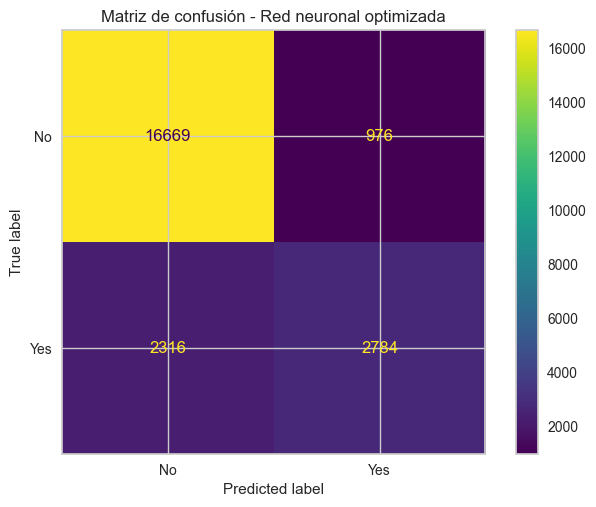

In [149]:
cm_nn_opt = confusion_matrix(y_validation, y_pred_nn_opt)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_nn_opt,
    display_labels=["No", "Yes"]
)

disp.plot()
plt.title("Matriz de confusión - Red neuronal optimizada")
plt.show()

En la evaluación externa sobre validation, la configuración destacada reduce los falsos positivos de 1016 a 976 frente a la red base, pero también reduce los verdaderos positivos de 2832 a 2784. Su F1 positivo es 0.6284, por lo que no mejora el F1 de la red base en esta partición externa.

Este resultado muestra que la configuración elegida en el subtrain interno no necesariamente mejora todas las métricas sobre una partición externa. Por eso, la selección final entre configuraciones se apoya posteriormente en las predicciones OOF sobre todo el conjunto de desarrollo.

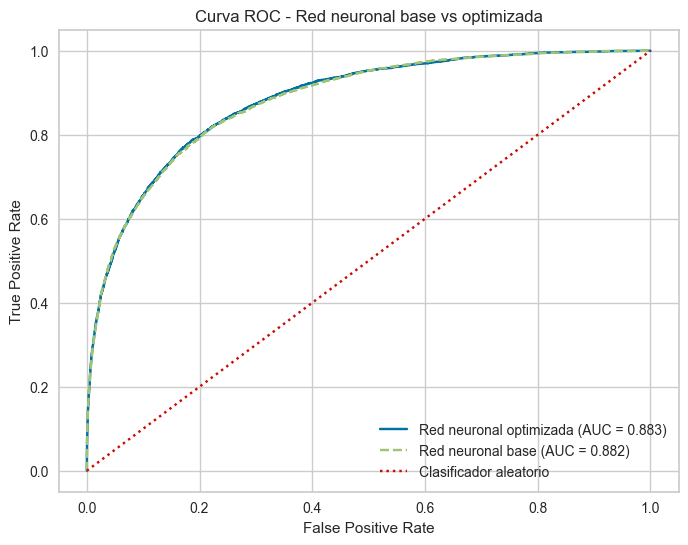

In [150]:
fpr_nn_opt, tpr_nn_opt, thresholds_nn_opt = roc_curve(
    y_validation,
    y_probabilidad_nn_opt
)

plt.figure(figsize=(8, 6))
plt.plot(
    fpr_nn_opt,
    tpr_nn_opt,
    label=f"Red neuronal optimizada (AUC = {auc_nn_opt:.3f})"
)

plt.plot(
    fpr_nn,
    tpr_nn,
    linestyle="--",
    label=f"Red neuronal base (AUC = {auc_nn:.3f})"
)

plt.plot([0, 1], [0, 1], linestyle=":", label="Clasificador aleatorio")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC - Red neuronal base vs optimizada")
plt.legend()
plt.show()

La búsqueda de hiperparámetros no produjo una mejora relevante en términos de ROC-AUC. Sin embargo, la matriz de confusión y las métricas de la clase positiva muestran que las distintas configuraciones modifican el equilibrio entre falsos positivos y falsos negativos.

Por este motivo, la comparación no se basa únicamente en AUC. Dado el desbalance del dataset, el F1-score de la clase "Yes" se mantiene como métrica principal en la posterior selección OOF.

## Explicabilidad de la red neuronal del benchmark

In [151]:
# El explainer recibe matrices transformadas por el preprocesador NN ajustado
# exclusivamente sobre X_train_nn_raw.
explainer = shap.DeepExplainer(nn_optimizada.model, X_train_nn[:100])
shap_values = explainer.shap_values(X_validation_nn)


### Gráficas a nivel local

In [152]:
index = 0
shap_values_sq = shap_values.squeeze(-1)
expected_value = float(explainer.expected_value[0])
explanation = shap.Explanation(
    values=shap_values_sq[index],
    base_values=expected_value,
    feature_names=feature_names_nn,
)


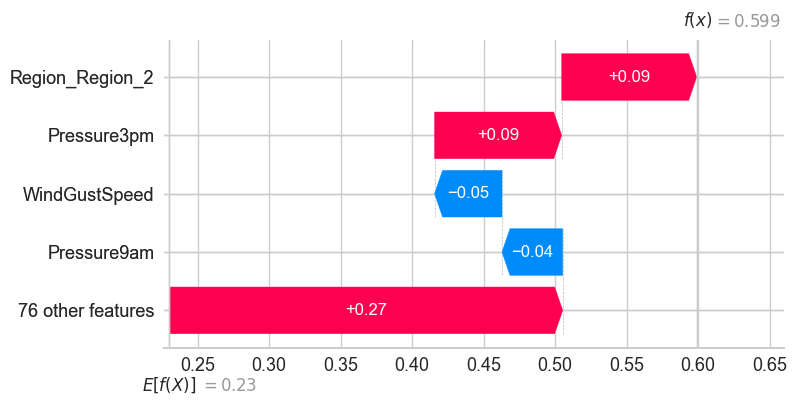

In [153]:
shap.plots.waterfall(explanation, max_display=5)

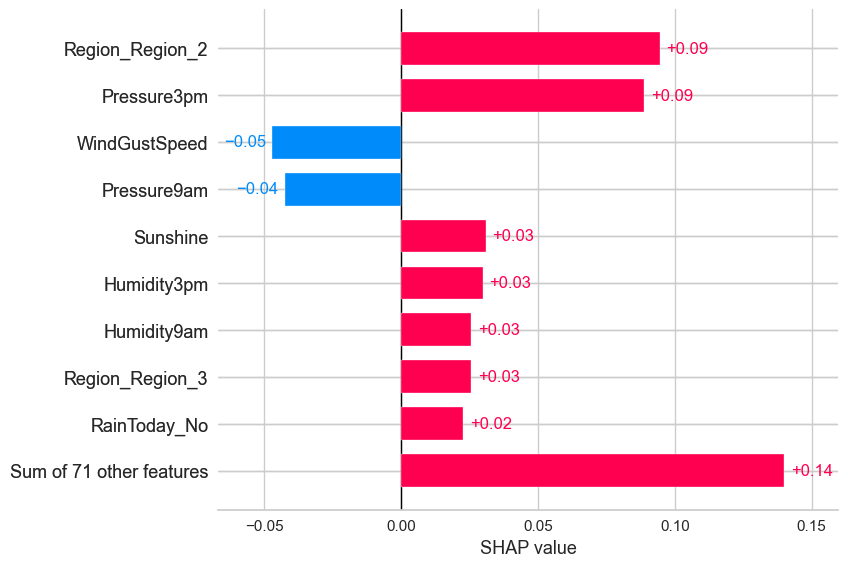

In [154]:
shap.plots.bar(explanation)

En las gráficas locales se analiza una predicción puntual de la red neuronal utilizada en este benchmark.

Para esta observación las variables que más influyen en la predicción son principalmente variables climáticas como humedad, presión, viento, temperatura. Algunas variables empujan la predicción hacia mayor probabilidad de lluvia, mientras que otras la empujan hacia menor probabilidad.

### Gráficas a nivel global

In [155]:
explanation = shap.Explanation(
    values=shap_values_sq,
    base_values=np.full(len(shap_values_sq), expected_value),
    feature_names=feature_names_nn,
    data=X_validation_nn,
)


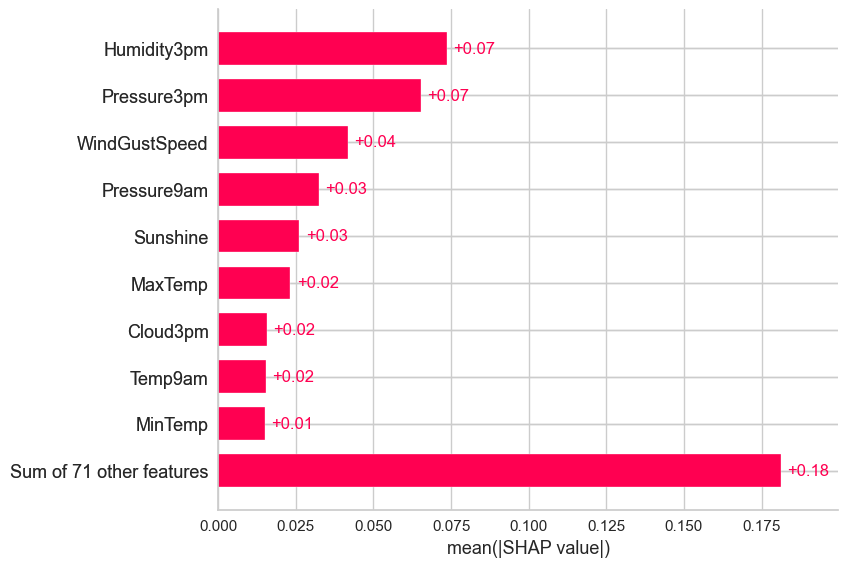

In [156]:
shap.plots.bar(explanation)

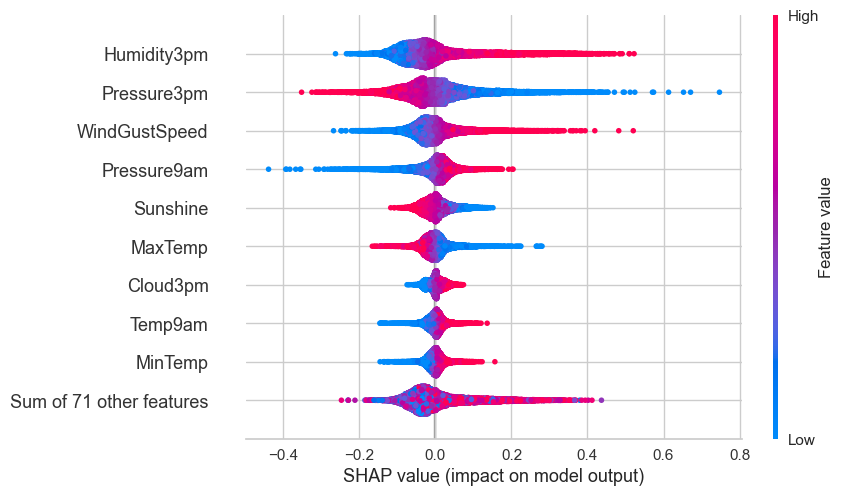

In [157]:
shap.plots.beeswarm(explanation)

En las gráficas globales de SHAP se observa que, considerando las variables individuales, las más importantes para la red neuronal analizada son `Humidity3pm`, `Pressure3pm`, `WindGustSpeed`, `Pressure9am`, `Sunshine`, `MaxTemp`, `Cloud3pm`, `Temp9am` y `MinTemp`.

La variable más importante es "Humidity3pm". En el beeswarm se ve que valores altos de humedad a las 3pm tienden a tener valores SHAP positivos, por lo que empujan la predicción hacia mayor probabilidad de lluvia. Esto tiene sentido, ya que una humedad alta suele estar asociada a condiciones más favorables para lluvia.

También se observa que "Pressure3pm" tiene mucha influencia. En este caso, los valores bajos de presión a las 3pm empujan la predicción hacia lluvia, mientras que los valores altos tienden a hacerlo en sentido contrario.

En "WindGustSpeed", los valores altos de velocidad de ráfaga tienden a aumentar la salida del modelo hacia la clase positiva, es decir, cuando hay ráfagas más fuertes, la red neuronal suele asociarlo con mayor probabilidad de lluvia.

Para las temperaturas, el comportamiento no es igual en todas las variables. En "MaxTemp", valores más bajos tienden a empujar más hacia lluvia, mientras que valores altos empujan más hacia no lluvia. En cambio, "Temp9am" muestra un efecto más mezclado aunque también aparece entre las variables relevantes.

En "Sunshine", los valores altos tienden a empujar la predicción hacia menor probabilidad de lluvia, mientras que valores bajos de sol tienden a acercarla más a lluvia. Esto es coherente con el problema, porque menos horas de sol suelen estar asociadas a mayor nubosidad o condiciones de lluvia.

"Cloud3pm" también aparece como una variable relevante: valores altos de nubosidad a las 3pm tienden a empujar la predicción hacia lluvia.

En resumen, la red neuronal basa sus predicciones principalmente en humedad, presión, viento, temperatura, sol y nubosidad. Los resultados son coherentes con el problema climático, ya que las variables que más influyen son justamente las que pueden anticipar condiciones de lluvia.

# Selección final con CV estratificada y probabilidades OOF
La selección final se realiza con una `StratifiedKFold` de 5 folds sobre todo el conjunto de desarrollo. Cada fila recibe una probabilidad out-of-fold (OOF) generada por un modelo que no utilizó esa observación durante su ajuste. Para cada candidato se elige el threshold que maximiza el F1 de la clase positiva sobre las probabilidades OOF; luego se comparan modelo, hiperparámetros y threshold utilizando ese mismo criterio. Precision, recall, PR-AUC y ROC-AUC se reportan como métricas complementarias. El conjunto de test queda reservado para la evaluación final.

In [158]:
from pathlib import Path
import json

ruta_metricas_oof = Path("artifacts/oof_candidate_metrics.csv")
ruta_seleccion_oof = Path("artifacts/oof_selection.json")
assert ruta_metricas_oof.is_file() and ruta_seleccion_oof.is_file()

metricas_oof = pd.read_csv(ruta_metricas_oof)
selection_oof = json.loads(ruta_seleccion_oof.read_text(encoding="utf-8"))
assert selection_oof["protocol"] == "single_stratified_5fold_oof"
assert selection_oof["primary_metric"] == "f1_positive"
assert selection_oof["final_test_features_used"] == 0
assert selection_oof["final_test_predictions_computed"] == 0

In [159]:
columnas_reporte = [
    "candidate_id", "family", "parameters", "threshold",
    "f1_positive", "precision", "recall", "pr_auc", "roc_auc",
]
df_comparacion = metricas_oof[columnas_reporte].sort_values(
    ["f1_positive", "candidate_id"], ascending=[False, True]
).reset_index(drop=True)
df_comparacion

,candidate_id,family,parameters,threshold,f1_positive,precision,recall,pr_auc,roc_auc
0,nn_config_5,NeuralNetwork,"{""batch_size"": 128, ""dropout_rate"": 0.4, ""epoc...",0.595796,0.659189,0.625053,0.697270,0.721426,0.881923
1,nn_config_3,NeuralNetwork,"{""batch_size"": 128, ""dropout_rate"": 0.3, ""epoc...",0.640645,0.657809,0.640806,0.675739,0.724763,0.881638
2,rf_default,RandomForest,"{""n_estimators"": 100}",0.430000,0.657429,0.606103,0.718252,0.716776,0.883133
3,nn_config_4,NeuralNetwork,"{""batch_size"": 64, ""dropout_rate"": 0.3, ""epoch...",0.623668,0.656929,0.622155,0.695819,0.725502,0.882051
4,nn_config_2,NeuralNetwork,"{""batch_size"": 64, ""dropout_rate"": 0.3, ""epoch...",0.607714,0.656740,0.613420,0.706644,0.726571,0.881861
5,nn_config_1,NeuralNetwork,"{""batch_size"": 64, ""dropout_rate"": 0.2, ""epoch...",0.594182,0.653026,0.607029,0.706565,0.722710,0.879829
6,lr_C=0.01_class_weight=None,LogisticRegression,"{""C"": 0.01, ""class_weight"": null}",0.617705,0.633172,0.594952,0.676641,0.689735,0.867277
7,lr_C=0.01_class_weight=balanced,LogisticRegression,"{""C"": 0.01, ""class_weight"": ""balanced""}",0.617705,0.633172,0.594952,0.676641,0.689735,0.867277
8,lr_C=0.1_class_weight=None,LogisticRegression,"{""C"": 0.1, ""class_weight"": null}",0.627983,0.633028,0.600796,0.668915,0.689126,0.867239
9,lr_C=0.1_class_weight=balanced,LogisticRegression,"{""C"": 0.1, ""class_weight"": ""balanced""}",0.627983,0.633028,0.600796,0.668915,0.689126,0.867239


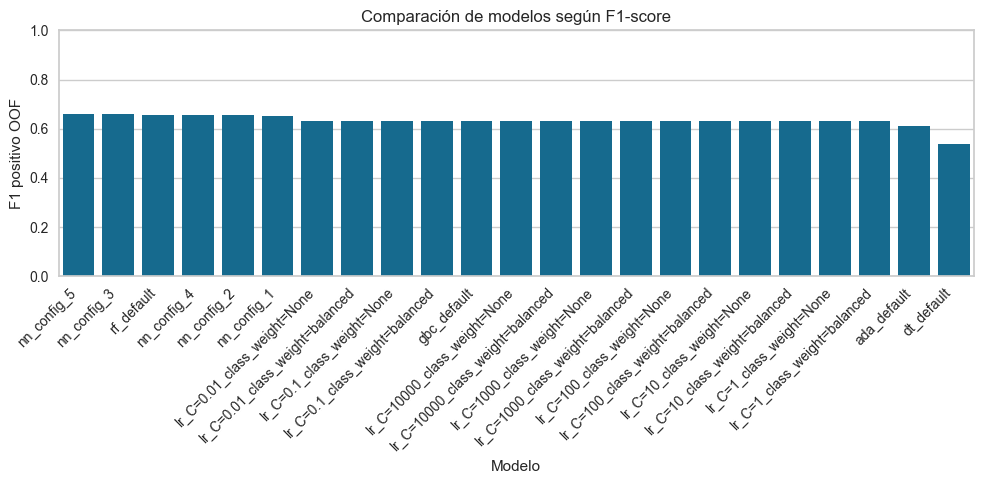

In [160]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=df_comparacion,
    x="candidate_id",
    y="f1_positive"
)

plt.title("Comparación de modelos según F1-score")
plt.xlabel("Modelo")
plt.ylabel("F1 positivo OOF")
plt.ylim(0, 1)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

El primer candidato de la tabla, la configuración `nn_config_5`, alcanza el mayor F1 OOF de la clase positiva con su threshold correspondiente y, por lo tanto, se selecciona como modelo final. Las métricas restantes permiten caracterizar el compromiso entre falsos positivos y falsos negativos.

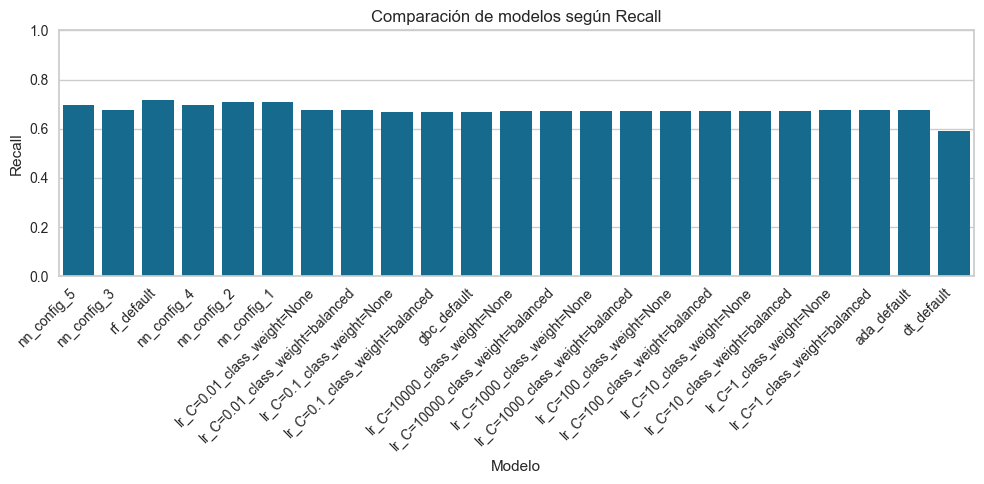

In [161]:

plt.figure(figsize=(10, 5))

sns.barplot(
    data=df_comparacion,
    x="candidate_id",
    y="recall"
)

plt.title("Comparación de modelos según Recall")
plt.xlabel("Modelo")
plt.ylabel("Recall")
plt.ylim(0, 1)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

El recall se interpreta de forma complementaria: un valor mayor puede estar acompañado por más falsos positivos y no reemplaza el criterio principal. La configuración seleccionada queda determinada por `f1_positive` OOF, junto con el threshold que maximiza esa métrica.

# Ajuste del pipeline seleccionado sobre desarrollo

In [162]:
# Comprobamos que la primera fila coincide con la selección registrada por OOF.
ganador_oof = selection_oof["winner"]
fila_ganadora = df_comparacion.iloc[0]
assert ganador_oof["candidate_id"] == fila_ganadora["candidate_id"]
assert np.isclose(ganador_oof["threshold"], fila_ganadora["threshold"])
assert np.isclose(
    ganador_oof["oof_metrics"]["f1_positive"],
    df_comparacion["f1_positive"].max(),
)

ruta_modelo_seleccionado = Path(selection_oof["frozen_model_artifact"])
assert ruta_modelo_seleccionado.is_file()
if selection_oof["frozen_model_format"] == "keras_plus_joblib_preprocessor":
    assert Path(selection_oof["frozen_preprocessor_artifact"]).is_file()
assert selection_oof["final_test_features_used"] == 0
assert selection_oof["final_test_predictions_computed"] == 0

print("CONFIGURACIÓN SELECCIONADA MEDIANTE OOF")
print(json.dumps(ganador_oof, indent=2, ensure_ascii=False))
print("Threshold OOF seleccionado:", ganador_oof["threshold"])


CONFIGURACIÓN SELECCIONADA MEDIANTE OOF
{
  "candidate_id": "nn_config_5",
  "family": "NeuralNetwork",
  "oof_metrics": {
    "f1_positive": 0.6591894998331541,
    "pr_auc": 0.7214264713644563,
    "precision": 0.6250527351989875,
    "recall": 0.6972703741469919,
    "roc_auc": 0.8819232920040554
  },
  "parameters": {
    "batch_size": 128,
    "dropout_rate": 0.4,
    "epochs": 50,
    "learning_rate": 0.0005
  },
  "threshold": 0.5957959890365601
}
Threshold OOF seleccionado: 0.5957959890365601


## Resultado de la selección OOF

La selección mediante probabilidades OOF de cinco folds identifica a `nn_config_5` como la configuración con mayor F1 de la clase positiva. Con la arquitectura, los hiperparámetros y el threshold ya seleccionados, el pipeline completo se ajusta sobre todo el conjunto de desarrollo. Este pipeline se utiliza en las evaluaciones temporal y final que se presentan a continuación.

# Evaluación temporal expansiva

Esta evaluación complementaria mide la robustez frente a observaciones cronológicamente posteriores. Utiliza cinco ventanas de validación sobre fechas completas y un conjunto de entrenamiento acumulativo. En cada ventana se aplica la configuración seleccionada mediante OOF y el mismo threshold, lo que permite comparar su desempeño temporal con el protocolo principal.

In [163]:
ruta_resumen_temporal = Path("artifacts/temporal_robustness.json")
ruta_folds_temporales = Path("artifacts/temporal_fold_metrics.csv")
assert ruta_resumen_temporal.is_file() and ruta_folds_temporales.is_file()

resumen_temporal = json.loads(ruta_resumen_temporal.read_text(encoding="utf-8"))
metricas_temporales = pd.read_csv(ruta_folds_temporales)
assert resumen_temporal["protocol"] == "expanding_window_temporal_robustness"
assert resumen_temporal["decision_impact"] == "none"
assert resumen_temporal["winner_candidate_id"] == selection_oof["winner"]["candidate_id"]
assert resumen_temporal["winner_parameters"] == selection_oof["winner"]["parameters"]
assert resumen_temporal["threshold"] == selection_oof["winner"]["threshold"]
assert resumen_temporal["threshold_optimized_temporally"] is False
assert resumen_temporal["frozen_artifacts_unchanged"] is True
assert resumen_temporal["final_test_predictions_computed"] == 0

In [164]:
columnas_temporales = [
    "fold", "train_start", "train_end", "validation_start",
    "validation_end", "train_rows", "validation_rows",
    "f1_positive", "precision", "recall", "pr_auc", "roc_auc",
]
display(metricas_temporales[columnas_temporales])
pd.DataFrame({
    "OOF principal": selection_oof["winner"]["oof_metrics"],
    "Temporal macro": resumen_temporal["temporal_macro_mean"],
    "Temporal pooled": resumen_temporal["temporal_pooled_metrics"],
})

,fold,train_start,train_end,validation_start,validation_end,train_rows,validation_rows,f1_positive,precision,recall,pr_auc,roc_auc
0,1,2007-11-01,2009-06-17,2009-06-18,2011-01-06,7942,20512,0.623322,0.591662,0.658561,0.690419,0.855054
1,2,2007-11-01,2011-01-06,2011-01-07,2012-08-26,28454,20504,0.654331,0.617460,0.695886,0.731080,0.871203
2,3,2007-11-01,2012-08-26,2012-08-27,2014-05-15,48958,21371,0.640790,0.631752,0.650090,0.701889,0.877505
3,4,2007-11-01,2014-05-15,2014-05-16,2015-12-04,70329,21573,0.628936,0.609108,0.650099,0.694051,0.875579
4,5,2007-11-01,2015-12-04,2015-12-05,2017-06-24,91902,21820,0.650066,0.608904,0.697197,0.720239,0.874138


,OOF principal,Temporal macro,Temporal pooled
f1_positive,0.659189,0.639489,0.639778
pr_auc,0.721426,0.707535,0.696414
precision,0.625053,0.611777,0.611164
recall,0.697270,0.670367,0.671203
roc_auc,0.881923,0.870696,0.863985


## Resultados de la evaluación temporal

El F1 positivo temporal medio fue 0.6395 y el resultado agregado fue 0.6398, frente a 0.6592 OOF en el protocolo principal. Los cinco folds se mantuvieron entre 0.6233 y 0.6543. Esto sugiere una degradación temporal moderada, sin una caída abrupta de robustez frente al paso del tiempo.

# Evaluación final sobre test

Finalmente, el pipeline seleccionado se evalúa sobre el 20% reservado como test. Esta partición permite estimar el desempeño sobre observaciones que no participaron en la comparación de modelos, el ajuste de hiperparámetros ni la selección del threshold.

In [165]:
ruta_resultado_test_final = Path("artifacts/final_test_metrics.json")
ruta_marcador_test_final = Path("artifacts/final_test_evaluation.completed.json")
assert ruta_resultado_test_final.is_file() and ruta_marcador_test_final.is_file()

resultado_test_final = json.loads(ruta_resultado_test_final.read_text(encoding="utf-8"))
assert resultado_test_final["protocol"] == "single_final_test_evaluation"
assert resultado_test_final["status"] == "complete"
assert resultado_test_final["decision_impact"] == "none"
assert resultado_test_final["test_prediction_calls"] == 1
assert resultado_test_final["fit_calls"] == 0
assert resultado_test_final["model_candidate_id"] == selection_oof["winner"]["candidate_id"]
assert resultado_test_final["model_parameters"] == selection_oof["winner"]["parameters"]
assert resultado_test_final["threshold"] == selection_oof["winner"]["threshold"]
assert resultado_test_final["frozen_artifacts_unchanged"] is True

In [166]:
display(pd.DataFrame({
    "Test final": resultado_test_final["test_metrics"],
    "OOF principal": resultado_test_final["reference_metrics"]["oof"],
    "Temporal macro": resultado_test_final["reference_metrics"]["temporal_macro"],
    "Temporal pooled": resultado_test_final["reference_metrics"]["temporal_pooled"],
}))

matriz_test_final = pd.DataFrame(
    resultado_test_final["confusion_matrix"]["matrix"],
    index=["Real No", "Real Yes"],
    columns=["Predicho No", "Predicho Yes"],
)
display(matriz_test_final)
display(pd.Series(resultado_test_final["prevalence"], name="Prevalencia test"))

,Test final,OOF principal,Temporal macro,Temporal pooled
f1_positive,0.653152,0.659189,0.639489,0.639778
pr_auc,0.734019,0.721426,0.707535,0.696414
precision,0.639645,0.625053,0.611777,0.611164
recall,0.667242,0.697270,0.670367,0.671203
roc_auc,0.885050,0.881923,0.870696,0.863985


,Predicho No,Predicho Yes
Real No,19661,2396
Real Yes,2121,4253


negative_rows    22057.000000
positive_rate        0.224192
positive_rows     6374.000000
Name: Prevalencia test, dtype: float64

## Cierre experimental

Con un threshold de 0.595796, el test final obtuvo F1 positivo 0.6532, precision 0.6396, recall 0.6672, PR-AUC 0.7340 y ROC-AUC 0.8851. La prevalencia positiva fue 22.42% y la matriz de confusión fue `[[19661, 2396], [2121, 4253]]`. El F1 quedó 0.0060 por debajo del resultado OOF principal y 0.0137 por encima de la media temporal, mostrando un desempeño consistente entre las tres perspectivas de evaluación.